# E-waste Battery Instance Segmentation: 8-model Colab Training Notebook

This notebook trains and evaluates the eight selected models/methods for the single-class e-waste battery instance segmentation task.

The notebook is organised as:

1. **Four YOLO-family segmentation models**
   - YOLOv5n-seg
   - YOLOv7-seg / YOLOv7-tiny-seg
   - YOLOv8n-seg
   - YOLO11n-seg

2. **Three established non-YOLO models**
   - Mask R-CNN R50-FPN
   - Cascade Mask R-CNN R50-FPN
   - PointRend Mask R-CNN

3. **One proposed hybrid method**
   - BatteryMask-RefineNet

This refined version adds A100-friendly runtime settings, mixed precision where supported, larger default batch sizes, periodic checkpointing to Google Drive, runtime logging, and the deployment-oriented hybrid method that refines actual YOLOv8n-seg predictions.


## 0. Runtime notes

Recommended Colab runtime:

- Hardware accelerator: **GPU**
- Preferred GPU: **A100**
- Runtime type: Python 3

Before running, confirm that `DATASET_ROOT` points to your dataset in Google Drive and that the dataset uses the YOLO segmentation layout:

```text
finaldata/
  data.yaml
  train/images
  train/labels
  val/images
  val/labels
  test/images
  test/labels
```

Each model writes to a separate folder in Google Drive, so running later sections should not overwrite earlier trained models.


In [ ]:
# ============================================================
# GPU check and A100-friendly global optimisation
# ============================================================

!nvidia-smi

import os
import random
import time
import json
from pathlib import Path

import numpy as np
import torch

def setup_gpu_optimisation(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    if torch.cuda.is_available():
        gpu_name = torch.cuda.get_device_name(0)
        print("GPU:", gpu_name)

        # Good when training image size is fixed, e.g. 640.
        torch.backends.cudnn.benchmark = True

        # A100 is an Ampere GPU. TF32 usually speeds up matmul/convolutions
        # with negligible practical impact for deep-learning training.
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True

        try:
            torch.set_float32_matmul_precision("high")
        except Exception as e:
            print("torch.set_float32_matmul_precision is unavailable:", e)

        print("cuDNN benchmark:", torch.backends.cudnn.benchmark)
        print("TF32 matmul allowed:", torch.backends.cuda.matmul.allow_tf32)
        print("TF32 cuDNN allowed:", torch.backends.cudnn.allow_tf32)

        if "A100" in gpu_name:
            print("A100 detected. A100-friendly settings are enabled.")
        else:
            print("A100 was not detected. The settings are still generally safe for CUDA GPUs.")
    else:
        print("CUDA is not available. Training on CPU is not recommended.")

setup_gpu_optimisation(seed=42)


Fri May  1 12:52:01 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   33C    P0             50W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

## 1. Mount Google Drive and define global paths

Change `DATASET_ROOT` if your dataset is stored somewhere else.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from pathlib import Path
import os, json, shutil, time, random, glob
import pandas as pd
import numpy as np

# ============================================================
# Main paths
# ============================================================

# ===== CHANGE THESE IF NEEDED =====
PROJECT_ROOT = Path('/content/drive/MyDrive/E-waste Battery Extraction CV')
DATASET_ROOT = Path('/content/drive/MyDrive/E-waste Battery Extraction CV/final_dataset')
YOLO_DATA_YAML = DATASET_ROOT / 'dataset.yaml'

# ============================================================
# General training settings
# ============================================================

SEED = 42
CLASS_NAMES = ['battery']
NUM_CLASSES = 1

IMG_SIZE = 640
SAVE_PERIOD_EPOCHS = 5

# A100-friendly defaults.
# Reduce these if you get CUDA out-of-memory.
YOLO_BATCH = 64             # For YOLOv5n, YOLOv8n, YOLO11n. Try 48/64 only if memory allows.
YOLOV7_BATCH = 32           # YOLOv7 repos are less predictable, so start lower.
DETECTRON2_IMS_PER_BATCH = 4
REFINE_BATCH_SIZE = 32

NUM_WORKERS = 4

EPOCHS_YOLO = 100
EPOCHS_DETECTRON2_APPROX = 100  # converted to iterations below
REFINE_EPOCHS = 40
REFINE_SAVE_EVERY = 5
REFINE_LR = 1e-4

# Keep this alias so old cells/functions that refer to BATCH_SIZE do not break.
BATCH_SIZE = YOLO_BATCH

# ============================================================
# Output folders
# ============================================================

YOLO_OUT = PROJECT_ROOT / '01_yolo_models'
D2_OUT = PROJECT_ROOT / '02_detectron2_models'
HYBRID_OUT = PROJECT_ROOT / '03_batterymask_refinenet'
METRICS_OUT = PROJECT_ROOT / '04_metrics_and_visualisations'

for p in [PROJECT_ROOT, YOLO_OUT, D2_OUT, HYBRID_OUT, METRICS_OUT]:
    p.mkdir(parents=True, exist_ok=True)

print('PROJECT_ROOT:', PROJECT_ROOT)
print('DATASET_ROOT:', DATASET_ROOT)
print('YOLO_DATA_YAML exists:', YOLO_DATA_YAML.exists())

# ============================================================
# Runtime logger
# ============================================================

runtime_log_path = PROJECT_ROOT / 'runtime_log.json'
runtime_records = []

def start_timer(model_name):
    print(f'===== Starting: {model_name} =====')
    return {'model': model_name, 'start_time': time.time()}

def stop_timer(record):
    record['end_time'] = time.time()
    record['duration_seconds'] = record['end_time'] - record['start_time']
    record['duration_minutes'] = record['duration_seconds'] / 60
    runtime_records.append(record)

    with open(runtime_log_path, 'w') as f:
        json.dump(runtime_records, f, indent=4)

    print(f"===== Finished: {record['model']} =====")
    print(f"Duration: {record['duration_minutes']:.2f} minutes")
    print('Runtime log saved to:', runtime_log_path)

def print_gpu_memory():
    if torch.cuda.is_available():
        allocated = torch.cuda.memory_allocated() / 1024**3
        reserved = torch.cuda.memory_reserved() / 1024**3
        max_allocated = torch.cuda.max_memory_allocated() / 1024**3
        print(f'Allocated memory: {allocated:.2f} GB')
        print(f'Reserved memory:   {reserved:.2f} GB')
        print(f'Max allocated:     {max_allocated:.2f} GB')
    else:
        print('CUDA is not available.')

print('YOLO_BATCH:', YOLO_BATCH)
print('YOLOV7_BATCH:', YOLOV7_BATCH)
print('DETECTRON2_IMS_PER_BATCH:', DETECTRON2_IMS_PER_BATCH)
print('REFINE_BATCH_SIZE:', REFINE_BATCH_SIZE)

PROJECT_ROOT: /content/drive/MyDrive/E-waste Battery Extraction CV
DATASET_ROOT: /content/drive/MyDrive/E-waste Battery Extraction CV/final_dataset
YOLO_DATA_YAML exists: True
YOLO_BATCH: 64
YOLOV7_BATCH: 32
DETECTRON2_IMS_PER_BATCH: 4
REFINE_BATCH_SIZE: 32


## 2. Basic dataset checks

This cell checks whether image and label folders exist and counts files. It does not modify the dataset.

In [ ]:
IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

def count_split(split):
    img_dir = DATASET_ROOT / 'images' / split
    lab_dir = DATASET_ROOT / 'labels' / split
    imgs = [p for p in img_dir.glob('*') if p.suffix.lower() in IMG_EXTS] if img_dir.exists() else []
    labs = list(lab_dir.glob('*.txt')) if lab_dir.exists() else []
    return len(imgs), len(labs)

for split in ['train', 'val', 'test']:
    ni, nl = count_split(split)
    print(f'{split:5s}: images={ni}, labels={nl}')

assert YOLO_DATA_YAML.exists(), f'Missing data.yaml at {YOLO_DATA_YAML}'

train: images=1235, labels=1235
val  : images=97, labels=97
test : images=97, labels=97


## 3. Install common packages

Ultralytics is used for YOLOv8n-seg and YOLO11n-seg. YOLOv5 and YOLOv7 are handled by their repositories later.

The notebook keeps each framework section separated so that a failure in YOLOv7 or Detectron2 does not delete previous results.

In [ ]:
!pip install -q ultralytics opencv-python pycocotools supervision roboflow
!pip install -q --force-reinstall pandas==2.2.2 scikit-image==0.25.2

import pandas as pd
import skimage
import torch

print("pandas:", pd.__version__)
print("scikit-image:", skimage.__version__)
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 78.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 30.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 195.8/195.8 kB 25.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 48.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 84.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 128.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 7.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 158.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.0/15.0 MB 151.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.6/3

# Group A — 4 YOLO-family segmentation models

The YOLO sections save each run to:

```text
MyDrive/e_waste_battery_segmentation_8_models/01_yolo_models/<model_name>/
```

For Ultralytics models, `save_period=5` saves intermediate checkpoints every 5 epochs. For YOLOv5/YOLOv7 repository scripts, the same idea is used through their `--save-period` argument when supported.

## 4. Train model 1 — YOLOv5n-seg

This section clones the YOLOv5 repository and trains the nano segmentation model.

If you already trained it, skip this section. It will not affect the other model folders.

In [ ]:
from pathlib import Path
import yaml

DATASET_ROOT = Path("/content/drive/MyDrive/E-waste Battery Extraction CV/final_dataset")
ORIGINAL_YAML = DATASET_ROOT / "dataset.yaml"
YOLOV5_DATA_YAML = "/content/drive/MyDrive/E-waste Battery Extraction CV/data_yolov5.yaml"

with open(ORIGINAL_YAML, "r") as f:
    data = yaml.safe_load(f)

# Force YOLOv5 to resolve relative paths from your dataset root.
data["path"] = str(DATASET_ROOT)

# Match your actual structure.
data["train"] = "images/train"
data["val"] = "images/val"
data["test"] = "images/test"

# Single-class battery dataset.
data["nc"] = 1
data["names"] = ["battery"]

with open(YOLOV5_DATA_YAML, "w") as f:
    yaml.safe_dump(data, f, sort_keys=False)

print("YOLOv5 YAML created at:", YOLOV5_DATA_YAML)
print("\nContent:")
with open(YOLOV5_DATA_YAML, "r") as f:
    print(f.read())

YOLOv5 YAML created at: /content/drive/MyDrive/E-waste Battery Extraction CV/data_yolov5.yaml

Content:
train: images/train
test: images/test
val: images/val
names:
- battery
path: /content/drive/MyDrive/E-waste Battery Extraction CV/final_dataset
nc: 1



In [ ]:
# ===== Model 1: YOLOv5n-seg =====
import os
os.environ["WANDB_DISABLED"] = "true"
os.environ["WANDB_MODE"] = "disabled"

YOLOV5_DIR = Path('/content/yolov5')
if not YOLOV5_DIR.exists():
    !git clone -q https://github.com/ultralytics/yolov5.git /content/yolov5

%cd /content/yolov5
!pip -q install -r requirements.txt

YOLOV5_RUN_NAME = 'model_01_yolov5n_seg'
YOLOV5_PROJECT = str(YOLO_OUT)

timer = start_timer('YOLOv5n-seg')

# A100 notes:
# - --cache ram can speed up training if RAM allows.
# - If RAM becomes a problem, change "--cache ram" to "--cache disk" or remove it.
!python segment/train.py \
    --img {IMG_SIZE} \
    --batch {YOLO_BATCH} \
    --epochs {EPOCHS_YOLO} \
    --data "{YOLOV5_DATA_YAML}" \
    --weights yolov5n-seg.pt \
    --project "{YOLOV5_PROJECT}" \
    --name "{YOLOV5_RUN_NAME}" \
    --workers {NUM_WORKERS} \
    --cache ram \
    --save-period {SAVE_PERIOD_EPOCHS} \
    --exist-ok \
    --device 0

stop_timer(timer)
print_gpu_memory()
%cd /content

/content/yolov5
===== Starting: YOLOv5n-seg =====
2026-04-28 02:45:25.077417: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777344325.099427    7402 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777344325.106695    7402 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777344325.125031    7402 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777344325.125062    7402 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777344325.125065    7402

## 5. Train model 2 — YOLOv7-seg / YOLOv7-tiny-seg

YOLOv7 segmentation has less standardised setup than Ultralytics YOLOv8/YOLO11. This cell tries the standard YOLOv7 repository workflow.

Use either:
- `yolov7-seg.pt`, or
- `yolov7-tiny-seg.pt` if your selected YOLOv7 segmentation repository provides it.

If this cell fails because the chosen repository does not expose `segment/train.py`, keep the failure as evidence and run the alternative YOLOv7 notebook/repository you selected. The output folder is still isolated from the other models.

In [ ]:
from pathlib import Path
import yaml

DATASET_ROOT = Path("/content/drive/MyDrive/E-waste Battery Extraction CV/final_dataset")
ORIGINAL_YAML = DATASET_ROOT / "dataset.yaml"
YOLOV7_DATA_YAML = "/content/drive/MyDrive/E-waste Battery Extraction CV/data_yolov7.yaml"

with open(ORIGINAL_YAML, "r") as f:
    data = yaml.safe_load(f)

# Force YOLOv7 to resolve relative paths from your dataset root.
data["path"] = str(DATASET_ROOT)

# Match your actual structure.
data["train"] = "images/train"
data["val"] = "images/val"
data["test"] = "images/test"

# Single-class battery dataset.
data["nc"] = 1
data["names"] = ["battery"]

with open(YOLOV7_DATA_YAML, "w") as f:
    yaml.safe_dump(data, f, sort_keys=False)

print("YOLOv7 YAML created at:", YOLOV7_DATA_YAML)
print("\nContent:")
with open(YOLOV7_DATA_YAML, "r") as f:
    print(f.read())

YOLOv7 YAML created at: /content/drive/MyDrive/E-waste Battery Extraction CV/data_yolov7.yaml

Content:
train: images/train
test: images/test
val: images/val
names:
- battery
path: /content/drive/MyDrive/E-waste Battery Extraction CV/final_dataset
nc: 1



In [ ]:
# ============================================================
# Delete old YOLO cache files after patching code
# ============================================================

from pathlib import Path

cache_files = [
    Path("/content/drive/MyDrive/E-waste Battery Extraction CV/final_dataset/labels/train.cache"),
    Path("/content/drive/MyDrive/E-waste Battery Extraction CV/final_dataset/labels/val.cache"),
    Path("/content/drive/MyDrive/E-waste Battery Extraction CV/final_dataset/labels/test.cache"),
    Path("/content/final_dataset/labels/train.cache"),
    Path("/content/final_dataset/labels/val.cache"),
    Path("/content/final_dataset/labels/test.cache"),
]

for cache_file in cache_files:
    if cache_file.exists():
        cache_file.unlink()
        print("Deleted:", cache_file)

Deleted: /content/drive/MyDrive/E-waste Battery Extraction CV/final_dataset/labels/train.cache
Deleted: /content/drive/MyDrive/E-waste Battery Extraction CV/final_dataset/labels/val.cache
Deleted: /content/drive/MyDrive/E-waste Battery Extraction CV/final_dataset/labels/test.cache


In [ ]:
# ===== Model 2: YOLOv7-seg / YOLOv7-tiny-seg =====
from pathlib import Path
import os

YOLOV7_SEG_DIR = Path("/content/yolov7-segmentation")

if not YOLOV7_SEG_DIR.exists():
    !git clone -q https://github.com/RizwanMunawar/yolov7-segmentation.git "{YOLOV7_SEG_DIR}"

%cd "{YOLOV7_SEG_DIR}"

# Avoid full requirements install if possible
#!pip install -q filterpy || true

# Patch torch.load for PyTorch >= 2.6
train_file = Path("/content/yolov7-segmentation/segment/train.py")
text = train_file.read_text()
old = "ckpt = torch.load(weights, map_location='cpu')"
new = "ckpt = torch.load(weights, map_location='cpu', weights_only=False)"

if old in text:
    train_file.write_text(text.replace(old, new))
    print("Patched train.py for PyTorch >= 2.6")
elif new in text:
    print("Patch already applied")
else:
    print("torch.load line not found; inspect train.py")

# Use your existing YAML
#YOLOV7_DATA_YAML = "/content/drive/MyDrive/E-waste Battery Extraction CV/data_yolov7.yaml"
print("Using YOLOv7 YAML:", YOLOV7_DATA_YAML)

# Download YOLOv7 segmentation weights if not present
if not Path("yolov7-seg.pt").exists():
    !wget -q -O yolov7-seg.pt https://github.com/WongKinYiu/yolov7/releases/download/v0.1/yolov7-seg.pt

YOLOV7_RUN_NAME = "model_02_yolov7_seg"
YOLOV7_PROJECT = str(YOLO_OUT)

timer = start_timer("YOLOv7-seg / YOLOv7-tiny-seg")

if Path("segment/train.py").exists():
    !python segment/train.py \
        --img {IMG_SIZE} \
        --batch {YOLOV7_BATCH} \
        --epochs {EPOCHS_YOLO} \
        --data "{YOLOV7_DATA_YAML}" \
        --weights yolov7-seg.pt \
        --project "{YOLOV7_PROJECT}" \
        --name "{YOLOV7_RUN_NAME}" \
        --workers {NUM_WORKERS} \
        --save-period {SAVE_PERIOD_EPOCHS} \
        --exist-ok \
        --noplots \
        --device 0
else:
    print("segment/train.py still not found.")
    !find . -maxdepth 3 -type f | head -100

stop_timer(timer)
print_gpu_memory()
%cd /content

/content/yolov7-segmentation
Patch already applied
Using YOLOv7 YAML: /content/drive/MyDrive/E-waste Battery Extraction CV/data_yolov7.yaml
===== Starting: YOLOv7-seg / YOLOv7-tiny-seg =====
2026-04-28 03:41:18.599446: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-28 03:41:18.618573: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777347678.640926   24491 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777347678.648305   24491 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plu

In [ ]:
from pathlib import Path

YOLOV7_RUN_DIR = Path("/content/drive/MyDrive/E-waste Battery Extraction CV/01_yolo_models/model_02_yolov7_seg")
WEIGHTS_DIR = YOLOV7_RUN_DIR / "weights"

for f in [WEIGHTS_DIR / "best.pt", WEIGHTS_DIR / "last.pt"]:
    print(f)
    print("Exists:", f.exists())
    if f.exists():
        print("Size MB:", f.stat().st_size / 1024**2)
    print()

/content/drive/MyDrive/E-waste Battery Extraction CV/01_yolo_models/model_02_yolov7_seg/weights/best.pt
Exists: True
Size MB: 289.84890842437744

/content/drive/MyDrive/E-waste Battery Extraction CV/01_yolo_models/model_02_yolov7_seg/weights/last.pt
Exists: True
Size MB: 289.84890842437744



## 6. Train model 3 — YOLOv8n-seg

This uses the Ultralytics Python API. Intermediate checkpoints are saved every 5 epochs.

In [ ]:
from pathlib import Path
import yaml

DATASET_ROOT = Path("/content/drive/MyDrive/E-waste Battery Extraction CV/final_dataset")
ORIGINAL_YAML = DATASET_ROOT / "dataset.yaml"
YOLOV8_DATA_YAML = "/content/drive/MyDrive/E-waste Battery Extraction CV/data_yolov8.yaml"

with open(ORIGINAL_YAML, "r") as f:
    data = yaml.safe_load(f)

# Force YOLOv8 to resolve relative paths from your dataset root.
data["path"] = str(DATASET_ROOT)

# Match your actual structure.
data["train"] = "images/train"
data["val"] = "images/val"
data["test"] = "images/test"

# Single-class battery dataset.
data["nc"] = 1
data["names"] = ["battery"]

with open(YOLOV8_DATA_YAML, "w") as f:
    yaml.safe_dump(data, f, sort_keys=False)

print("YOLOv8 YAML created at:", YOLOV8_DATA_YAML)
print("\nContent:")
with open(YOLOV8_DATA_YAML, "r") as f:
    print(f.read())

YOLOv8 YAML created at: /content/drive/MyDrive/E-waste Battery Extraction CV/data_yolov8.yaml

Content:
train: images/train
test: images/test
val: images/val
names:
- battery
path: /content/drive/MyDrive/E-waste Battery Extraction CV/final_dataset
nc: 1



In [ ]:
# ===== Model 3: YOLOv8n-seg =====
from ultralytics import YOLO

timer = start_timer('YOLOv8n-seg')

model = YOLO('yolov8n-seg.pt')
results = model.train(
    data=str(YOLO_DATA_YAML),
    imgsz=IMG_SIZE,
    batch=YOLO_BATCH,
    epochs=EPOCHS_YOLO,
    project=str(YOLO_OUT),
    name='model_03_yolov8n_seg',
    save=True,
    save_period=SAVE_PERIOD_EPOCHS,
    exist_ok=True,
    seed=SEED,
    device=0,
    workers=8,
    amp=True,
    cache=True,
    patience=25,
    plots=True,
    verbose=True
)

stop_timer(timer)
print_gpu_memory()
print('YOLOv8n-seg saved to:', YOLO_OUT / 'model_03_yolov8n_seg')

===== Starting: YOLOv8n-seg =====
Ultralytics 8.4.42 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/E-waste Battery Extraction CV/final_dataset/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=model

## 7. Train model 4 — YOLO11n-seg

This uses the same Ultralytics training API as YOLOv8n-seg.

In [ ]:
from pathlib import Path
import yaml

DATASET_ROOT = Path("/content/drive/MyDrive/E-waste Battery Extraction CV/final_dataset")
ORIGINAL_YAML = DATASET_ROOT / "dataset.yaml"
YOLOV11_DATA_YAML = "/content/drive/MyDrive/E-waste Battery Extraction CV/data_yolov11.yaml"

with open(ORIGINAL_YAML, "r") as f:
    data = yaml.safe_load(f)

# Force YOLOv8 to resolve relative paths from your dataset root.
data["path"] = str(DATASET_ROOT)

# Match your actual structure.
data["train"] = "images/train"
data["val"] = "images/val"
data["test"] = "images/test"

# Single-class battery dataset.
data["nc"] = 1
data["names"] = ["battery"]

with open(YOLOV11_DATA_YAML, "w") as f:
    yaml.safe_dump(data, f, sort_keys=False)

print("YOLOv11 YAML created at:", YOLOV11_DATA_YAML)
print("\nContent:")
with open(YOLOV11_DATA_YAML, "r") as f:
    print(f.read())

YOLOv11 YAML created at: /content/drive/MyDrive/E-waste Battery Extraction CV/data_yolov11.yaml

Content:
train: images/train
test: images/test
val: images/val
names:
- battery
path: /content/drive/MyDrive/E-waste Battery Extraction CV/final_dataset
nc: 1



In [ ]:
# ===== Model 4: YOLO11n-seg =====
from ultralytics import YOLO

timer = start_timer('YOLO11n-seg')

model = YOLO('yolo11n-seg.pt')
results = model.train(
    data=str(YOLO_DATA_YAML),
    imgsz=IMG_SIZE,
    batch=YOLO_BATCH,
    epochs=EPOCHS_YOLO,
    project=str(YOLO_OUT),
    name='model_04_yolo11n_seg',
    save=True,
    save_period=SAVE_PERIOD_EPOCHS,
    exist_ok=True,
    seed=SEED,
    device=0,
    workers=8,
    amp=True,
    cache=True,
    patience=25,
    plots=True,
    verbose=True
)

stop_timer(timer)
print_gpu_memory()
print('YOLO11n-seg saved to:', YOLO_OUT / 'model_04_yolo11n_seg')

===== Starting: YOLO11n-seg =====
Ultralytics 8.4.42 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/E-waste Battery Extraction CV/final_dataset/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=model

## Optional. Train model - YOLO26n-seg

This uses the same Ultralytics training API as YOLOv8n-seg.

In [ ]:
from pathlib import Path
import yaml

DATASET_ROOT = Path("/content/drive/MyDrive/E-waste Battery Extraction CV/final_dataset")
ORIGINAL_YAML = DATASET_ROOT / "dataset.yaml"
YOLO26_DATA_YAML = "/content/drive/MyDrive/E-waste Battery Extraction CV/data_yolo26.yaml"

with open(ORIGINAL_YAML, "r") as f:
    data = yaml.safe_load(f)

# Force YOLOv8 to resolve relative paths from your dataset root.
data["path"] = str(DATASET_ROOT)

# Match your actual structure.
data["train"] = "images/train"
data["val"] = "images/val"
data["test"] = "images/test"

# Single-class battery dataset.
data["nc"] = 1
data["names"] = ["battery"]

with open(YOLO26_DATA_YAML, "w") as f:
    yaml.safe_dump(data, f, sort_keys=False)

print("YOLO26 YAML created at:", YOLO26_DATA_YAML)
print("\nContent:")
with open(YOLO26_DATA_YAML, "r") as f:
    print(f.read())

YOLO26 YAML created at: /content/drive/MyDrive/E-waste Battery Extraction CV/data_yolo26.yaml

Content:
train: images/train
test: images/test
val: images/val
names:
- battery
path: /content/drive/MyDrive/E-waste Battery Extraction CV/final_dataset
nc: 1



In [ ]:
# ===== Optional Model: YOLO26n-seg =====
# This is an optional extra YOLO-family model.
# It does not overwrite your existing 8 models.

from ultralytics import YOLO
from pathlib import Path

YOLO26_RUN_NAME = "optional_yolo26n_seg"
YOLO26_PROJECT = str(YOLO_OUT)

timer = start_timer("YOLO26n-seg")

model = YOLO("yolo26n-seg.pt")

results = model.train(
    data=str(YOLO_DATA_YAML),     # or your local YAML, if you are using /content/final_dataset
    epochs=EPOCHS_YOLO,
    imgsz=IMG_SIZE,
    batch=YOLO_BATCH,                    # safe on A100 40GB for nano
    workers=8,
    device=0,
    amp=True,
    cache=True,
    save=True,
    save_period=SAVE_PERIOD_EPOCHS,
    project=YOLO26_PROJECT,
    name=YOLO26_RUN_NAME,
    exist_ok=True,
    patience=25,
    plots=True
)

stop_timer(timer)
print_gpu_memory()

===== Starting: YOLO26n-seg =====
Ultralytics 8.4.42 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/E-waste Battery Extraction CV/final_dataset/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=optio

# Dataset conversion for Detectron2

Detectron2 works most cleanly with COCO-format instance segmentation annotations. The next cell converts your YOLO polygon labels into COCO JSON files for train/val/test.

The generated COCO files are saved into Google Drive, so you only need to run this conversion once unless your dataset changes.

In [ ]:
import cv2
from PIL import Image
from tqdm import tqdm

COCO_DIR = PROJECT_ROOT / 'coco_annotations'
COCO_DIR.mkdir(parents=True, exist_ok=True)

def yolo_seg_to_coco(split):
    img_dir = DATASET_ROOT / 'images' / split
    lab_dir = DATASET_ROOT / 'labels' / split
    out_json = COCO_DIR / f'{split}.json'

    images = []
    annotations = []
    ann_id = 1
    img_id = 1

    img_paths = sorted([p for p in img_dir.glob('*') if p.suffix.lower() in IMG_EXTS])

    for img_path in tqdm(img_paths, desc=f'Converting {split}'):
        try:
            with Image.open(img_path) as im:
                w, h = im.size
        except Exception as e:
            print('Skipping unreadable image:', img_path, e)
            continue

        images.append({
            'id': img_id,
            'file_name': img_path.name,
            'width': w,
            'height': h
        })

        label_path = lab_dir / f'{img_path.stem}.txt'
        if label_path.exists():
            lines = label_path.read_text().strip().splitlines()
            for line in lines:
                parts = line.strip().split()
                if len(parts) < 7:
                    continue

                cls_id = int(float(parts[0]))
                coords = list(map(float, parts[1:]))
                if len(coords) % 2 != 0:
                    coords = coords[:-1]

                poly = []
                xs, ys = [], []
                for i in range(0, len(coords), 2):
                    x = coords[i] * w
                    y = coords[i+1] * h
                    poly.extend([x, y])
                    xs.append(x)
                    ys.append(y)

                if len(xs) < 3:
                    continue

                x_min, x_max = max(0, min(xs)), min(w, max(xs))
                y_min, y_max = max(0, min(ys)), min(h, max(ys))
                box_w, box_h = x_max - x_min, y_max - y_min
                if box_w <= 1 or box_h <= 1:
                    continue

                # polygon area
                pts = np.array(poly, dtype=np.float32).reshape(-1, 2)
                area = float(abs(cv2.contourArea(pts)))

                annotations.append({
                    'id': ann_id,
                    'image_id': img_id,
                    'category_id': 1,  # COCO category ids start from 1
                    'segmentation': [poly],
                    'bbox': [float(x_min), float(y_min), float(box_w), float(box_h)],
                    'area': area,
                    'iscrowd': 0
                })
                ann_id += 1

        img_id += 1

    coco = {
        'images': images,
        'annotations': annotations,
        'categories': [{'id': 1, 'name': 'battery', 'supercategory': 'object'}]
    }
    with open(out_json, 'w') as f:
        json.dump(coco, f)

    print(f'Saved {out_json}: images={len(images)}, annotations={len(annotations)}')
    return out_json

train_json = yolo_seg_to_coco('train')
val_json = yolo_seg_to_coco('val')
test_json = yolo_seg_to_coco('test')

Converting train: 100%|██████████| 1235/1235 [00:12<00:00, 100.57it/s]


Saved /content/drive/MyDrive/E-waste Battery Extraction CV/coco_annotations/train.json: images=1235, annotations=1237


Converting val: 100%|██████████| 97/97 [00:00<00:00, 193.02it/s]


Saved /content/drive/MyDrive/E-waste Battery Extraction CV/coco_annotations/val.json: images=97, annotations=97


Converting test: 100%|██████████| 97/97 [02:21<00:00,  1.46s/it]

Saved /content/drive/MyDrive/E-waste Battery Extraction CV/coco_annotations/test.json: images=97, annotations=97


# Group B — 3 established non-YOLO models using Detectron2

The three established non-YOLO models are:

5. `Mask R-CNN R50-FPN`
6. `Cascade Mask R-CNN R50-FPN`
7. `PointRend Mask R-CNN`

Each model is saved into a separate Google Drive folder:

```text
MyDrive/e_waste_battery_segmentation_8_models/02_detectron2_models/<model_name>/
```

## 8. Install Detectron2

If installation fails because Colab changes its CUDA/PyTorch version, restart runtime and rerun from this cell. Detectron2 is more version-sensitive than Ultralytics.

In [ ]:
# 1. Install dependencies
!pip install pyyaml==5.1
import torch

# 2. Check Torch and CUDA versions to ensure compatibility
TORCH_VERSION = ".".join(torch.__version__.split(".")[:2])
CUDA_VERSION = torch.__version__.split("+")[-1]
print(f"Torch: {TORCH_VERSION}; CUDA: {CUDA_VERSION}")

# 3. Install Detectron2 from source (most reliable for Colab)
!python -m pip install 'git+https://github.com/facebookresearch/detectron2.git'

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 274.2/274.2 kB 6.6 MB/s eta 0:00:00
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.
Torch: 2.10; CUDA: cu128
  Cloning https://github.com/facebookresearch/detectron2.git to /tmp/pip-req-build-y86ydiq6
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/detectron2.git /tmp/pip-req-build-y86ydiq6
  Resolved https://github.com/facebookresearch/detectron2.git to commit b599f139756bd3646a26a909caf86a1a159e53a7
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import detectron2
from detectron2.utils.logger import setup_logger
setup_logger()
print(detectron2.__version__)

0.6


## 9. Register the COCO datasets for Detectron2

This does not train anything. It only tells Detectron2 where the train/validation/test data are.

In [ ]:
from detectron2.data.datasets import register_coco_instances
from detectron2.data import MetadataCatalog, DatasetCatalog

def safe_register_coco(name, json_file, image_root):
    if name in DatasetCatalog.list():
        DatasetCatalog.remove(name)
        MetadataCatalog.remove(name)
    register_coco_instances(name, {}, str(json_file), str(image_root))

safe_register_coco('battery_train', COCO_DIR / 'train.json', DATASET_ROOT / 'images' / 'train')
safe_register_coco('battery_val', COCO_DIR / 'val.json', DATASET_ROOT / 'images' / 'val')
safe_register_coco('battery_test', COCO_DIR / 'test.json', DATASET_ROOT / 'images' / 'test')

battery_metadata = MetadataCatalog.get('battery_train')
battery_metadata.thing_classes = CLASS_NAMES

print('Registered datasets:', [d for d in DatasetCatalog.list() if d.startswith('battery_')])

Registered datasets: ['battery_train', 'battery_val', 'battery_test']


## 10. Detectron2 training helper

This helper trains one Detectron2 model and saves checkpoints to Drive. The checkpoint interval is set approximately every `SAVE_PERIOD_EPOCHS`.

In [ ]:
import os, math, json, time
import torch
from detectron2.engine import DefaultTrainer, DefaultPredictor
from detectron2.config import get_cfg
from detectron2 import model_zoo
from detectron2.evaluation import COCOEvaluator, inference_on_dataset
from detectron2.data import build_detection_test_loader

def count_coco_images(json_path):
    with open(json_path, 'r') as f:
        data = json.load(f)
    return len(data['images'])

TRAIN_IMAGE_COUNT = count_coco_images(COCO_DIR / 'train.json')
ITER_PER_EPOCH = max(1, math.ceil(TRAIN_IMAGE_COUNT / DETECTRON2_IMS_PER_BATCH))
MAX_ITER = EPOCHS_DETECTRON2_APPROX * ITER_PER_EPOCH
CHECKPOINT_PERIOD = SAVE_PERIOD_EPOCHS * ITER_PER_EPOCH

print('TRAIN_IMAGE_COUNT:', TRAIN_IMAGE_COUNT)
print('ITER_PER_EPOCH:', ITER_PER_EPOCH)
print('MAX_ITER:', MAX_ITER)
print('CHECKPOINT_PERIOD:', CHECKPOINT_PERIOD)

def train_detectron2_model(
    model_name,
    config_file,
    output_dir,
    lr=0.0005,
    ims_per_batch=DETECTRON2_IMS_PER_BATCH,
    num_workers=NUM_WORKERS,
    roi_batch_size_per_image=64,
    extra_cfg_func=None,
    weights=None
):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    cfg = get_cfg()

    # PointRend needs extra config before merging.
    if extra_cfg_func is not None:
        extra_cfg_func(cfg)

    cfg.merge_from_file(config_file)
    cfg.DATASETS.TRAIN = ('battery_train',)
    cfg.DATASETS.TEST = ('battery_val',)
    cfg.DATALOADER.NUM_WORKERS = num_workers

    if weights is not None:
        cfg.MODEL.WEIGHTS = weights
    else:
        try:
            cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url(config_file)
        except Exception:
            cfg.MODEL.WEIGHTS = ''

    # A100-friendly settings.
    cfg.SOLVER.IMS_PER_BATCH = ims_per_batch
    cfg.SOLVER.BASE_LR = lr
    cfg.SOLVER.MAX_ITER = MAX_ITER
    cfg.SOLVER.STEPS = []
    cfg.SOLVER.CHECKPOINT_PERIOD = CHECKPOINT_PERIOD

    # Mixed precision for Detectron2.
    try:
        cfg.SOLVER.AMP.ENABLED = True
    except Exception as e:
        print('AMP setting could not be enabled for this Detectron2 config:', e)

    # Fixed image size helps speed and stability.
    cfg.INPUT.MIN_SIZE_TRAIN = (IMG_SIZE,)
    cfg.INPUT.MAX_SIZE_TRAIN = IMG_SIZE
    cfg.INPUT.MIN_SIZE_TEST = IMG_SIZE
    cfg.INPUT.MAX_SIZE_TEST = IMG_SIZE

    cfg.MODEL.ROI_HEADS.BATCH_SIZE_PER_IMAGE = roi_batch_size_per_image
    cfg.MODEL.ROI_HEADS.NUM_CLASSES = NUM_CLASSES

    # Required for PointRend models
    if hasattr(cfg.MODEL, "POINT_HEAD"):
        cfg.MODEL.POINT_HEAD.NUM_CLASSES = 1
    cfg.OUTPUT_DIR = str(output_dir)

    # Ensure masks are enabled.
    cfg.MODEL.MASK_ON = True

    os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)
    with open(output_dir / 'config_used.yaml', 'w') as f:
        f.write(cfg.dump())

    trainer = DefaultTrainer(cfg)
    trainer.resume_or_load(resume=False)

    timer = start_timer(model_name)
    trainer.train()
    stop_timer(timer)
    print_gpu_memory()

    # Evaluate on validation set.
    cfg.MODEL.WEIGHTS = str(output_dir / 'model_final.pth')
    predictor = DefaultPredictor(cfg)
    evaluator = COCOEvaluator('battery_val', cfg, False, output_dir=str(output_dir / 'eval_val'))
    val_loader = build_detection_test_loader(cfg, 'battery_val')
    metrics = inference_on_dataset(predictor.model, val_loader, evaluator)

    with open(output_dir / 'eval_metrics.json', 'w') as f:
        json.dump(metrics, f, indent=2)

    print(f'Finished {model_name}. Output:', output_dir)
    print(metrics)
    return cfg, metrics

TRAIN_IMAGE_COUNT: 1235
ITER_PER_EPOCH: 309
MAX_ITER: 30900
CHECKPOINT_PERIOD: 1545


## 11. Train model 5 — Mask R-CNN R50-FPN

This is the classical two-stage instance segmentation baseline.

In [ ]:
# ===== Model 5: Mask R-CNN R50-FPN =====
mask_rcnn_config = model_zoo.get_config_file('COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml')
mask_rcnn_out = D2_OUT / 'model_05_mask_rcnn_R50_FPN'

cfg_mask, metrics_mask = train_detectron2_model(
    model_name='Mask R-CNN R50-FPN',
    config_file=mask_rcnn_config,
    output_dir=mask_rcnn_out,
    lr=0.0005,
    ims_per_batch=DETECTRON2_IMS_PER_BATCH
)

## 12. Train model 6 — PointRend Mask R-CNN

PointRend is included because battery extraction can benefit from better mask boundaries.

In [ ]:
# ============================================================
# Safe PointRend access after it has already been registered
# ============================================================

import sys

# Case 1: PointRend was imported as detectron2.projects.point_rend
if "detectron2.projects.point_rend" in sys.modules:
    point_rend_module = sys.modules["detectron2.projects.point_rend"]
    add_pointrend_config = point_rend_module.add_pointrend_config
    print("Using existing detectron2.projects.point_rend module.")

# Case 2: PointRend was imported as point_rend
elif "point_rend" in sys.modules:
    point_rend_module = sys.modules["point_rend"]
    add_pointrend_config = point_rend_module.add_pointrend_config
    print("Using existing point_rend module.")

# Case 3: first clean import
else:
    from detectron2.projects import point_rend as point_rend_module
    add_pointrend_config = point_rend_module.add_pointrend_config
    print("Imported PointRend from detectron2.projects.")

print("add_pointrend_config is ready:", callable(add_pointrend_config))

Using existing detectron2.projects.point_rend module.
add_pointrend_config is ready: True


In [ ]:
from detectron2.config import get_cfg

cfg = get_cfg()
add_pointrend_config(cfg)

pointrend_config = "/content/detectron2_repo/projects/PointRend/configs/InstanceSegmentation/pointrend_rcnn_R_50_FPN_3x_coco.yaml"
cfg.merge_from_file(pointrend_config)

In [ ]:
# ===== Define PointRend config function safely =====
# This avoids: from point_rend import add_pointrend_config
# because importing the full point_rend package can double-register PointRendMaskHead.

from pathlib import Path
import importlib.util

POINTRD_CONFIG_PY = Path("/content/detectron2_repo/projects/PointRend/point_rend/config.py")

print("PointRend config.py exists:", POINTRD_CONFIG_PY.exists())
assert POINTRD_CONFIG_PY.exists(), f"Missing file: {POINTRD_CONFIG_PY}"

spec = importlib.util.spec_from_file_location(
    "pointrend_config_only",
    str(POINTRD_CONFIG_PY)
)

pointrend_config_module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(pointrend_config_module)

add_pointrend_config = pointrend_config_module.add_pointrend_config

print("add_pointrend_config defined:", callable(add_pointrend_config))

PointRend config.py exists: True
add_pointrend_config defined: True


In [ ]:
# ===== Model 7: PointRend Mask R-CNN =====
from pathlib import Path

pointrend_config = "/content/detectron2_repo/projects/PointRend/configs/InstanceSegmentation/pointrend_rcnn_R_50_FPN_3x_coco.yaml"
assert Path(pointrend_config).exists(), f"Missing PointRend config: {pointrend_config}"

pointrend_out = D2_OUT / "model_07_pointrend_mask_rcnn_R50_FPN"

cfg_pointrend, metrics_pointrend = train_detectron2_model(
    model_name="PointRend Mask R-CNN",
    config_file=pointrend_config,
    output_dir=pointrend_out,
    lr=0.0005,
    ims_per_batch=DETECTRON2_IMS_PER_BATCH,
    extra_cfg_func=add_pointrend_config
)

# Group C — Proposed hybrid method

## 13. Model 7 — BatteryMask-RefineNet, deployment-oriented version

This section replaces the earlier simulated-mask refinement idea with a more deployment-realistic hybrid method.

The method uses the trained `YOLOv8n-seg` model as the coarse segmentation stage, then trains a lightweight crop-level refinement network using the actual masks predicted by YOLOv8n-seg.

The pipeline is:

```text
image
→ trained YOLOv8n-seg
→ actual YOLO coarse mask
→ RGB crop + coarse mask crop
→ BatteryMask-RefineNet
→ refined battery mask
```

This section does not modify or retrain the first seven models. It only loads the saved YOLOv8n-seg weights and writes new files into the `03_batterymask_refinenet` folder.


In [ ]:
# ============================================================
# BatteryMask-RefineNet setup
# This cell does not overwrite the first seven model outputs.
# ============================================================

import os, json, math, random, time
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Using device:', DEVICE)

# Separate output folder for the deployment-oriented hybrid method.
HYBRID_DEPLOY_OUT = HYBRID_OUT / 'model_08_batterymask_refinenet_deployable'
COARSE_MASK_ROOT = HYBRID_DEPLOY_OUT / '01_yolov8n_actual_coarse_masks'
PAIR_ROOT = HYBRID_DEPLOY_OUT / '02_refiner_training_pairs'
REFINE_CKPT_DIR = HYBRID_DEPLOY_OUT / '03_checkpoints'
REFINE_RESULT_DIR = HYBRID_DEPLOY_OUT / '04_results'
REFINE_VIS_DIR = HYBRID_DEPLOY_OUT / '05_visualisations'

for p in [HYBRID_DEPLOY_OUT, COARSE_MASK_ROOT, PAIR_ROOT, REFINE_CKPT_DIR, REFINE_RESULT_DIR, REFINE_VIS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

# Trained YOLOv8n-seg best weight from model 3.
YOLOV8N_BEST_PT = YOLO_OUT / 'model_03_yolov8n_seg' / 'weights' / 'best.pt'
print('YOLOv8n best weight expected at:', YOLOV8N_BEST_PT)
print('Exists:', YOLOV8N_BEST_PT.exists())

# Refiner settings.
CROP_SIZE = 256
REFINE_EPOCHS = 40
REFINE_BATCH_SIZE = 8
REFINE_LR = 1e-4
REFINE_SAVE_EVERY = 5
REFINE_BBOX_PAD = 30
REFINE_CONF = 0.25

# For reproducibility.
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if DEVICE == 'cuda':
    torch.cuda.manual_seed_all(SEED)

# A100 note: REFINE_BATCH_SIZE, REFINE_EPOCHS, REFINE_SAVE_EVERY and REFINE_LR are defined globally.


## 14.1 Utility functions

These functions convert YOLO polygon labels into masks, compute mask IoU, compute centroid error, and create image overlays for qualitative checking.


In [ ]:
# ============================================================
# Utility functions for masks, metrics, and visualisation
# ============================================================

IMAGE_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

def list_images(image_dir):
    image_dir = Path(image_dir)
    return sorted([p for p in image_dir.glob('*') if p.suffix.lower() in IMAGE_EXTS])


def yolo_seg_label_to_mask(label_path, image_shape):
    """
    Convert a YOLO segmentation label file to a binary mask.

    Expected format per line:
    class_id x1 y1 x2 y2 x3 y3 ...

    Coordinates are normalised in [0, 1]. Since this is a single-class
    battery task, polygons are merged into one binary mask.
    """
    h, w = image_shape[:2]
    mask = np.zeros((h, w), dtype=np.uint8)

    label_path = Path(label_path)
    if not label_path.exists():
        return mask

    with open(label_path, 'r') as f:
        lines = f.readlines()

    for line in lines:
        parts = line.strip().split()
        if len(parts) < 7:
            continue

        coords = np.array(parts[1:], dtype=np.float32)
        if len(coords) % 2 != 0:
            coords = coords[:-1]

        pts = coords.reshape(-1, 2)
        pts[:, 0] *= w
        pts[:, 1] *= h
        pts = np.round(pts).astype(np.int32)

        if len(pts) >= 3:
            cv2.fillPoly(mask, [pts], 1)

    return mask


def get_mask_bbox(mask, pad=20):
    ys, xs = np.where(mask > 0)
    if len(xs) == 0 or len(ys) == 0:
        return None

    h, w = mask.shape[:2]
    x1 = max(int(xs.min()) - pad, 0)
    y1 = max(int(ys.min()) - pad, 0)
    x2 = min(int(xs.max()) + pad + 1, w)
    y2 = min(int(ys.max()) + pad + 1, h)
    return x1, y1, x2, y2


def bbox_from_union(mask_a, mask_b, pad=20):
    union = ((mask_a > 0) | (mask_b > 0)).astype(np.uint8)
    return get_mask_bbox(union, pad=pad)


def resize_binary_mask(mask, size):
    resized = cv2.resize(mask.astype(np.uint8), size, interpolation=cv2.INTER_NEAREST)
    return (resized > 0).astype(np.uint8)


def mask_iou(pred_mask, gt_mask, eps=1e-7):
    pred = pred_mask.astype(bool)
    gt = gt_mask.astype(bool)
    inter = np.logical_and(pred, gt).sum()
    union = np.logical_or(pred, gt).sum()
    if union == 0:
        return 1.0 if inter == 0 else 0.0
    return float(inter / (union + eps))


def mask_pixel_precision_recall(pred_mask, gt_mask, eps=1e-7):
    pred = pred_mask.astype(bool)
    gt = gt_mask.astype(bool)
    tp = np.logical_and(pred, gt).sum()
    fp = np.logical_and(pred, ~gt).sum()
    fn = np.logical_and(~pred, gt).sum()
    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)
    return float(precision), float(recall)


def mask_centroid(mask):
    ys, xs = np.where(mask > 0)
    if len(xs) == 0:
        return None
    return float(xs.mean()), float(ys.mean())


def centroid_error(pred_mask, gt_mask):
    pred_c = mask_centroid(pred_mask)
    gt_c = mask_centroid(gt_mask)
    if pred_c is None or gt_c is None:
        return np.nan
    return float(math.sqrt((pred_c[0] - gt_c[0]) ** 2 + (pred_c[1] - gt_c[1]) ** 2))


def overlay_mask(image_rgb, mask, alpha=0.45):
    image_rgb = image_rgb.copy()
    overlay = image_rgb.copy()
    overlay[mask > 0] = (0, 255, 0)
    return cv2.addWeighted(overlay, alpha, image_rgb, 1 - alpha, 0)


## 14.2 Generate actual YOLOv8n coarse masks

This cell loads the trained YOLOv8n-seg model from model 3 and runs it on the train, validation, and test images. The predicted masks are saved as coarse masks. These are the masks used by the proposed refinement method.


In [ ]:
# ============================================================
# Generate actual YOLOv8n predicted masks
# ============================================================

from ultralytics import YOLO

assert YOLOV8N_BEST_PT.exists(), (
    f'YOLOv8n best.pt was not found at {YOLOV8N_BEST_PT}. '
    'Run model 3 first, or update YOLOV8N_BEST_PT to the correct path.'
)

yolov8n_for_refine = YOLO(str(YOLOV8N_BEST_PT))
print('Loaded YOLOv8n-seg from:', YOLOV8N_BEST_PT)


def save_yolo_predicted_masks(model, image_dir, output_dir, conf=0.25, imgsz=640):
    """
    Run YOLOv8n-seg and save one binary coarse mask per image.
    If multiple battery masks are predicted, they are merged into one mask.
    """
    image_dir = Path(image_dir)
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    image_paths = list_images(image_dir)
    print(f'Predicting {len(image_paths)} images from {image_dir}')

    for img_path in tqdm(image_paths):
        img_bgr = cv2.imread(str(img_path))
        if img_bgr is None:
            continue

        h, w = img_bgr.shape[:2]
        coarse_mask = np.zeros((h, w), dtype=np.uint8)

        result = model.predict(
            source=str(img_path),
            conf=conf,
            imgsz=imgsz,
            verbose=False
        )[0]

        if result.masks is not None:
            masks = result.masks.data.detach().cpu().numpy()
            for m in masks:
                m_resized = cv2.resize(m, (w, h), interpolation=cv2.INTER_LINEAR)
                coarse_mask = np.maximum(coarse_mask, (m_resized > 0.5).astype(np.uint8))

        cv2.imwrite(str(output_dir / f'{img_path.stem}.png'), coarse_mask * 255)

    print('Saved coarse masks to:', output_dir)


save_yolo_predicted_masks(yolov8n_for_refine, DATASET_ROOT / 'train' / 'images', COARSE_MASK_ROOT / 'train', REFINE_CONF, IMG_SIZE)
save_yolo_predicted_masks(yolov8n_for_refine, DATASET_ROOT / 'val' / 'images', COARSE_MASK_ROOT / 'val', REFINE_CONF, IMG_SIZE)
save_yolo_predicted_masks(yolov8n_for_refine, DATASET_ROOT / 'test' / 'images', COARSE_MASK_ROOT / 'test', REFINE_CONF, IMG_SIZE)


## 14.3 Create crop-level training pairs

The refiner is trained using real YOLOv8n coarse masks. Each `.npz` file stores:

- RGB crop
- YOLOv8n coarse mask crop
- ground-truth mask crop
- crop metadata

The crop is taken around the union of the ground-truth and coarse mask during training/evaluation pair creation. During real inference, the crop is taken from the YOLO coarse mask only.


In [ ]:
# ============================================================
# Create refiner training pairs from actual YOLO coarse masks
# ============================================================

def create_refiner_pairs(split_name):
    image_dir = DATASET_ROOT / split_name / 'images'
    label_dir = DATASET_ROOT / split_name / 'labels'
    coarse_dir = COARSE_MASK_ROOT / split_name
    out_dir = PAIR_ROOT / split_name
    out_dir.mkdir(parents=True, exist_ok=True)

    image_paths = list_images(image_dir)
    saved = 0
    skipped = 0

    for img_path in tqdm(image_paths, desc=f'Creating refiner pairs for {split_name}'):
        img_bgr = cv2.imread(str(img_path))
        if img_bgr is None:
            skipped += 1
            continue

        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        h, w = img_rgb.shape[:2]

        gt_mask = yolo_seg_label_to_mask(label_dir / f'{img_path.stem}.txt', img_rgb.shape)

        coarse_path = coarse_dir / f'{img_path.stem}.png'
        if coarse_path.exists():
            coarse_mask = cv2.imread(str(coarse_path), cv2.IMREAD_GRAYSCALE)
            coarse_mask = (coarse_mask > 127).astype(np.uint8)
        else:
            coarse_mask = np.zeros((h, w), dtype=np.uint8)

        # Use the union for supervised pair generation, so the crop includes both
        # the predicted area and the true target area when YOLO is slightly off.
        bbox = bbox_from_union(gt_mask, coarse_mask, pad=REFINE_BBOX_PAD)
        if bbox is None:
            skipped += 1
            continue

        x1, y1, x2, y2 = bbox
        rgb_crop = img_rgb[y1:y2, x1:x2]
        coarse_crop = coarse_mask[y1:y2, x1:x2]
        gt_crop = gt_mask[y1:y2, x1:x2]

        rgb_crop = cv2.resize(rgb_crop, (CROP_SIZE, CROP_SIZE), interpolation=cv2.INTER_LINEAR)
        coarse_crop = resize_binary_mask(coarse_crop, (CROP_SIZE, CROP_SIZE))
        gt_crop = resize_binary_mask(gt_crop, (CROP_SIZE, CROP_SIZE))

        np.savez_compressed(
            out_dir / f'{img_path.stem}.npz',
            rgb=rgb_crop.astype(np.uint8),
            coarse=coarse_crop.astype(np.uint8),
            gt=gt_crop.astype(np.uint8),
            image_name=img_path.name,
            bbox=np.array([x1, y1, x2, y2], dtype=np.int32),
            original_size=np.array([h, w], dtype=np.int32)
        )
        saved += 1

    print(f'{split_name}: saved={saved}, skipped={skipped}')


create_refiner_pairs('train')
create_refiner_pairs('val')
create_refiner_pairs('test')


## 14.4 Define the refiner dataset and model

BatteryMask-RefineNet is a small U-Net-style model. Its input has four channels: RGB plus the YOLOv8n coarse mask. Its output is a refined binary battery mask.


In [ ]:
# ============================================================
# Dataset, model, and loss for BatteryMask-RefineNet
# ============================================================

class BatteryRefinerDataset(Dataset):
    def __init__(self, pair_dir, augment=False):
        self.pair_dir = Path(pair_dir)
        self.files = sorted(self.pair_dir.glob('*.npz'))
        self.augment = augment

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        data = np.load(self.files[idx], allow_pickle=True)
        rgb = data['rgb'].astype(np.float32) / 255.0
        coarse = data['coarse'].astype(np.float32)
        gt = data['gt'].astype(np.float32)

        if self.augment:
            if random.random() < 0.5:
                rgb = np.flip(rgb, axis=1).copy()
                coarse = np.flip(coarse, axis=1).copy()
                gt = np.flip(gt, axis=1).copy()
            if random.random() < 0.5:
                rgb = np.flip(rgb, axis=0).copy()
                coarse = np.flip(coarse, axis=0).copy()
                gt = np.flip(gt, axis=0).copy()

        x = np.concatenate([rgb, coarse[..., None]], axis=-1)
        x = torch.from_numpy(x).permute(2, 0, 1).float()
        y = torch.from_numpy(gt[None, ...]).float()
        return x, y


class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class BatteryMaskRefineNet(nn.Module):
    def __init__(self, in_channels=4, base_channels=32):
        super().__init__()
        self.enc1 = ConvBlock(in_channels, base_channels)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = ConvBlock(base_channels, base_channels * 2)
        self.pool2 = nn.MaxPool2d(2)
        self.enc3 = ConvBlock(base_channels * 2, base_channels * 4)
        self.pool3 = nn.MaxPool2d(2)

        self.bottleneck = ConvBlock(base_channels * 4, base_channels * 8)

        self.up3 = nn.ConvTranspose2d(base_channels * 8, base_channels * 4, 2, stride=2)
        self.dec3 = ConvBlock(base_channels * 8, base_channels * 4)
        self.up2 = nn.ConvTranspose2d(base_channels * 4, base_channels * 2, 2, stride=2)
        self.dec2 = ConvBlock(base_channels * 4, base_channels * 2)
        self.up1 = nn.ConvTranspose2d(base_channels * 2, base_channels, 2, stride=2)
        self.dec1 = ConvBlock(base_channels * 2, base_channels)

        self.out = nn.Conv2d(base_channels, 1, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))
        b = self.bottleneck(self.pool3(e3))

        d3 = self.up3(b)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)
        return self.out(d1)


def dice_loss_with_logits(logits, targets, eps=1e-7):
    probs = torch.sigmoid(logits)
    inter = (probs * targets).sum(dim=(1, 2, 3))
    union = probs.sum(dim=(1, 2, 3)) + targets.sum(dim=(1, 2, 3))
    dice = (2 * inter + eps) / (union + eps)
    return 1 - dice.mean()


def combined_loss(logits, targets):
    bce = nn.functional.binary_cross_entropy_with_logits(logits, targets)
    dice = dice_loss_with_logits(logits, targets)
    return bce + dice


train_ds = BatteryRefinerDataset(PAIR_ROOT / 'train', augment=True)
val_ds = BatteryRefinerDataset(PAIR_ROOT / 'val', augment=False)
test_ds = BatteryRefinerDataset(PAIR_ROOT / 'test', augment=False)

print('Train pairs:', len(train_ds))
print('Val pairs:', len(val_ds))
print('Test pairs:', len(test_ds))

train_loader = DataLoader(
    train_ds,
    batch_size=REFINE_BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=(NUM_WORKERS > 0)
)
val_loader = DataLoader(
    val_ds,
    batch_size=REFINE_BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=(NUM_WORKERS > 0)
)
test_loader = DataLoader(
    test_ds,
    batch_size=1,
    shuffle=False,
    num_workers=1,
    pin_memory=True
)

refiner = BatteryMaskRefineNet(in_channels=4, base_channels=32).to(DEVICE)
optimizer = torch.optim.AdamW(refiner.parameters(), lr=REFINE_LR, weight_decay=1e-4)
print(refiner)


## 14.5 Train BatteryMask-RefineNet

Checkpoints are saved to Google Drive every 5 epochs. The best checkpoint is selected using validation crop-level mask IoU.


In [ ]:
# ============================================================
# Train BatteryMask-RefineNet with A100-friendly AMP
# ============================================================

from torch.cuda.amp import autocast, GradScaler

scaler = GradScaler(enabled=torch.cuda.is_available())

@torch.no_grad()
def evaluate_refiner_crop(model, loader):
    model.eval()
    losses, ious = [], []
    precisions, recalls = [], []

    for x, y in loader:
        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)

        with autocast(enabled=torch.cuda.is_available()):
            logits = model(x)
            loss = combined_loss(logits, y)

        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).float()

        losses.append(float(loss.item()))

        for i in range(preds.size(0)):
            pred_np = preds[i, 0].detach().cpu().numpy().astype(np.uint8)
            gt_np = y[i, 0].detach().cpu().numpy().astype(np.uint8)
            ious.append(mask_iou(pred_np, gt_np))
            p, r = mask_pixel_precision_recall(pred_np, gt_np)
            precisions.append(p)
            recalls.append(r)

    return {
        'loss': float(np.mean(losses)) if losses else np.nan,
        'crop_mean_iou': float(np.mean(ious)) if ious else np.nan,
        'crop_pixel_precision': float(np.mean(precisions)) if precisions else np.nan,
        'crop_pixel_recall': float(np.mean(recalls)) if recalls else np.nan,
    }


best_val_iou = -1.0
history = []
timer = start_timer('BatteryMask-RefineNet')

for epoch in range(1, REFINE_EPOCHS + 1):
    refiner.train()
    train_losses = []

    for x, y in tqdm(train_loader, desc=f'Refiner epoch {epoch}/{REFINE_EPOCHS}'):
        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with autocast(enabled=torch.cuda.is_available()):
            logits = refiner(x)
            loss = combined_loss(logits, y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_losses.append(float(loss.item()))

    val_metrics = evaluate_refiner_crop(refiner, val_loader)
    row = {
        'epoch': epoch,
        'train_loss': float(np.mean(train_losses)) if train_losses else np.nan,
        **{f'val_{k}': v for k, v in val_metrics.items()}
    }
    history.append(row)

    print(
        f"Epoch {epoch:03d} | "
        f"train_loss={row['train_loss']:.4f} | "
        f"val_loss={row['val_loss']:.4f} | "
        f"val_crop_mean_iou={row['val_crop_mean_iou']:.4f}"
    )

    if epoch % REFINE_SAVE_EVERY == 0:
        ckpt_path = REFINE_CKPT_DIR / f'batterymask_refinenet_epoch_{epoch:03d}.pth'
        torch.save({
            'epoch': epoch,
            'model_state_dict': refiner.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_metrics': val_metrics,
            'history': history,
            'settings': {
                'crop_size': CROP_SIZE,
                'bbox_pad': REFINE_BBOX_PAD,
                'coarse_source': str(YOLOV8N_BEST_PT),
                'amp': torch.cuda.is_available(),
                'batch_size': REFINE_BATCH_SIZE
            }
        }, ckpt_path)
        print('Saved checkpoint:', ckpt_path)

    if val_metrics['crop_mean_iou'] > best_val_iou:
        best_val_iou = val_metrics['crop_mean_iou']
        best_path = REFINE_CKPT_DIR / 'batterymask_refinenet_best.pth'
        torch.save({
            'epoch': epoch,
            'model_state_dict': refiner.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_metrics': val_metrics,
            'history': history,
            'settings': {
                'crop_size': CROP_SIZE,
                'bbox_pad': REFINE_BBOX_PAD,
                'coarse_source': str(YOLOV8N_BEST_PT),
                'amp': torch.cuda.is_available(),
                'batch_size': REFINE_BATCH_SIZE
            }
        }, best_path)
        print('Saved new best model:', best_path)

stop_timer(timer)
print_gpu_memory()

history_df = pd.DataFrame(history)
history_csv = REFINE_RESULT_DIR / 'batterymask_refinenet_training_history.csv'
history_df.to_csv(history_csv, index=False)
display(history_df.tail())
print('Training history saved to:', history_csv)
print('Best validation crop IoU:', best_val_iou)


## 14.6 Full-image deployable inference and evaluation

This is the actual proposed deployment path:

```text
image → YOLOv8n-seg coarse mask → crop from coarse mask → refiner → paste refined crop back into full image
```

The cell compares YOLOv8n coarse masks against refined masks using mean mask IoU and centroid error.


In [ ]:
# ============================================================
# Full-image inference with the deployable hybrid pipeline
# ============================================================

best_ckpt_path = REFINE_CKPT_DIR / 'batterymask_refinenet_best.pth'
assert best_ckpt_path.exists(), 'Train the refiner first or update best_ckpt_path.'

best_ckpt = torch.load(best_ckpt_path, map_location=DEVICE)
refiner_eval = BatteryMaskRefineNet(in_channels=4, base_channels=32).to(DEVICE)
refiner_eval.load_state_dict(best_ckpt['model_state_dict'])
refiner_eval.eval()

print('Loaded best BatteryMask-RefineNet checkpoint from epoch:', best_ckpt['epoch'])


@torch.no_grad()
def refine_full_image(image_rgb, coarse_mask, crop_size=CROP_SIZE, pad=REFINE_BBOX_PAD):
    """
    Deployment-like inference:
    - crop from YOLO coarse mask only
    - run the refiner
    - paste the refined crop back into full image size
    """
    h, w = image_rgb.shape[:2]
    bbox = get_mask_bbox(coarse_mask, pad=pad)

    if bbox is None:
        return np.zeros((h, w), dtype=np.uint8)

    x1, y1, x2, y2 = bbox
    rgb_crop = image_rgb[y1:y2, x1:x2]
    coarse_crop = coarse_mask[y1:y2, x1:x2]
    crop_h, crop_w = coarse_crop.shape[:2]

    rgb_resized = cv2.resize(rgb_crop, (crop_size, crop_size), interpolation=cv2.INTER_LINEAR)
    coarse_resized = resize_binary_mask(coarse_crop, (crop_size, crop_size))

    rgb_float = rgb_resized.astype(np.float32) / 255.0
    x = np.concatenate([rgb_float, coarse_resized[..., None]], axis=-1)
    x = torch.from_numpy(x).permute(2, 0, 1).unsqueeze(0).float().to(DEVICE)

    logits = refiner_eval(x)
    pred_crop = (torch.sigmoid(logits)[0, 0].detach().cpu().numpy() > 0.5).astype(np.uint8)
    pred_crop_full_size = cv2.resize(pred_crop, (crop_w, crop_h), interpolation=cv2.INTER_NEAREST)

    refined = np.zeros((h, w), dtype=np.uint8)
    refined[y1:y2, x1:x2] = pred_crop_full_size
    return refined


def load_coarse_mask(image_path, split_name):
    img_bgr = cv2.imread(str(image_path))
    h, w = img_bgr.shape[:2]
    coarse_path = COARSE_MASK_ROOT / split_name / f'{Path(image_path).stem}.png'
    if not coarse_path.exists():
        return np.zeros((h, w), dtype=np.uint8)
    coarse = cv2.imread(str(coarse_path), cv2.IMREAD_GRAYSCALE)
    return (coarse > 127).astype(np.uint8)


def evaluate_full_image_refinement(split_name):
    image_dir = DATASET_ROOT / split_name / 'images'
    label_dir = DATASET_ROOT / split_name / 'labels'
    image_paths = list_images(image_dir)

    pred_dir = REFINE_RESULT_DIR / f'{split_name}_refined_masks'
    pred_dir.mkdir(parents=True, exist_ok=True)

    rows = []
    for img_path in tqdm(image_paths, desc=f'Evaluating deployable hybrid on {split_name}'):
        img_bgr = cv2.imread(str(img_path))
        if img_bgr is None:
            continue
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

        gt_mask = yolo_seg_label_to_mask(label_dir / f'{img_path.stem}.txt', img_rgb.shape)
        coarse_mask = load_coarse_mask(img_path, split_name)
        refined_mask = refine_full_image(img_rgb, coarse_mask)

        cv2.imwrite(str(pred_dir / f'{img_path.stem}.png'), refined_mask * 255)

        coarse_iou = mask_iou(coarse_mask, gt_mask)
        refined_iou = mask_iou(refined_mask, gt_mask)
        coarse_ce = centroid_error(coarse_mask, gt_mask)
        refined_ce = centroid_error(refined_mask, gt_mask)
        coarse_p, coarse_r = mask_pixel_precision_recall(coarse_mask, gt_mask)
        refined_p, refined_r = mask_pixel_precision_recall(refined_mask, gt_mask)

        rows.append({
            'image': img_path.name,
            'coarse_mask_iou': coarse_iou,
            'refined_mask_iou': refined_iou,
            'delta_iou': refined_iou - coarse_iou,
            'coarse_pixel_precision': coarse_p,
            'coarse_pixel_recall': coarse_r,
            'refined_pixel_precision': refined_p,
            'refined_pixel_recall': refined_r,
            'coarse_centroid_error_px': coarse_ce,
            'refined_centroid_error_px': refined_ce,
            'delta_centroid_error_px': refined_ce - coarse_ce,
        })

    df = pd.DataFrame(rows)
    csv_path = REFINE_RESULT_DIR / f'{split_name}_full_image_refinement_metrics.csv'
    df.to_csv(csv_path, index=False)

    summary = {
        'split': split_name,
        'num_images': len(df),
        'mean_coarse_mask_iou': df['coarse_mask_iou'].mean(),
        'mean_refined_mask_iou': df['refined_mask_iou'].mean(),
        'mean_delta_iou': df['delta_iou'].mean(),
        'mean_coarse_pixel_precision': df['coarse_pixel_precision'].mean(),
        'mean_coarse_pixel_recall': df['coarse_pixel_recall'].mean(),
        'mean_refined_pixel_precision': df['refined_pixel_precision'].mean(),
        'mean_refined_pixel_recall': df['refined_pixel_recall'].mean(),
        'mean_coarse_centroid_error_px': df['coarse_centroid_error_px'].mean(),
        'mean_refined_centroid_error_px': df['refined_centroid_error_px'].mean(),
        'mean_delta_centroid_error_px': df['delta_centroid_error_px'].mean(),
    }

    print('Saved per-image metrics to:', csv_path)
    return df, summary


val_refine_df, val_refine_summary = evaluate_full_image_refinement('val')
test_refine_df, test_refine_summary = evaluate_full_image_refinement('test')

hybrid_summary_df = pd.DataFrame([val_refine_summary, test_refine_summary])
hybrid_summary_csv = REFINE_RESULT_DIR / 'batterymask_refinenet_deployable_summary.csv'
hybrid_summary_df.to_csv(hybrid_summary_csv, index=False)

display(hybrid_summary_df)
print('Saved hybrid summary to:', hybrid_summary_csv)


# 15. Final 9-metric summary table

This table collects the standard 9 metrics from the YOLO and Detectron2 outputs:

1. Box Precision  
2. Box Recall  
3. Box mAP50  
4. Box mAP50-95  
5. Mask Precision  
6. Mask Recall  
7. Mask mAP50  
8. Mask mAP50-95  
9. Inference ms/img  

For BatteryMask-RefineNet, the model is a refinement module rather than a detector, so the official COCO-style box metrics are not directly applicable. The notebook therefore also saves a task-specific hybrid summary with mean mask IoU and centroid error.


## Optional: export the deployable hybrid method to ONNX

The proposed method is a two-stage pipeline, so deployment normally uses two ONNX files:

1. `yolov8n_seg.onnx`
2. `BatteryMaskRefineNet.onnx`

The deterministic crop, resize, paste-back, contour, and centroid steps remain in the deployment script.


In [ ]:
# ============================================================
# Optional ONNX export for the deployable hybrid pipeline
# ============================================================

EXPORT_ONNX = False  # Change to True when you want to export.

if EXPORT_ONNX:
    # 1) Export YOLOv8n-seg.
    yolo_export_model = YOLO(str(YOLOV8N_BEST_PT))
    yolo_export_path = yolo_export_model.export(
        format='onnx',
        imgsz=IMG_SIZE,
        opset=12,
        simplify=True
    )
    print('YOLOv8n ONNX exported to:', yolo_export_path)

    # 2) Export BatteryMaskRefineNet.
    best_ckpt_path = REFINE_CKPT_DIR / 'batterymask_refinenet_best.pth'
    best_ckpt = torch.load(best_ckpt_path, map_location=DEVICE)

    export_refiner = BatteryMaskRefineNet(in_channels=4, base_channels=32).to(DEVICE)
    export_refiner.load_state_dict(best_ckpt['model_state_dict'])
    export_refiner.eval()

    dummy_input = torch.randn(1, 4, CROP_SIZE, CROP_SIZE, device=DEVICE)
    refiner_onnx_path = HYBRID_DEPLOY_OUT / 'BatteryMaskRefineNet.onnx'

    torch.onnx.export(
        export_refiner,
        dummy_input,
        str(refiner_onnx_path),
        input_names=['rgb_plus_coarse_mask'],
        output_names=['refined_mask_logits'],
        opset_version=12,
        dynamic_axes={
            'rgb_plus_coarse_mask': {0: 'batch_size'},
            'refined_mask_logits': {0: 'batch_size'}
        }
    )

    print('BatteryMaskRefineNet ONNX exported to:', refiner_onnx_path)
else:
    print('ONNX export skipped. Set EXPORT_ONNX = True to export.')


In [ ]:
# ============================================================
# Collect final metrics for the eight methods
# ============================================================

def latest_results_csv(run_dir):
    paths = list(Path(run_dir).rglob('results.csv'))
    if not paths:
        return None
    return sorted(paths, key=lambda p: p.stat().st_mtime)[-1]


def read_yolo_metrics(model_label, run_dir):
    csv_path = latest_results_csv(run_dir)
    row = {
        'Model': model_label,
        'Box Precision': np.nan,
        'Box Recall': np.nan,
        'Box mAP50': np.nan,
        'Box mAP50-95': np.nan,
        'Mask Precision': np.nan,
        'Mask Recall': np.nan,
        'Mask mAP50': np.nan,
        'Mask mAP50-95': np.nan,
        'Inference ms/img': np.nan,
        'Source': str(run_dir),
    }

    if csv_path is None:
        print('No YOLO results.csv found for', model_label)
        return row

    df = pd.read_csv(csv_path)
    last = df.iloc[-1]

    def get_any(names):
        for n in names:
            if n in last.index:
                return float(last[n])
        return np.nan

    row['Box Precision'] = get_any(['metrics/precision(B)', 'metrics/precision'])
    row['Box Recall'] = get_any(['metrics/recall(B)', 'metrics/recall'])
    row['Box mAP50'] = get_any(['metrics/mAP50(B)', 'metrics/mAP_0.5'])
    row['Box mAP50-95'] = get_any(['metrics/mAP50-95(B)', 'metrics/mAP_0.5:0.95'])
    row['Mask Precision'] = get_any(['metrics/precision(M)'])
    row['Mask Recall'] = get_any(['metrics/recall(M)'])
    row['Mask mAP50'] = get_any(['metrics/mAP50(M)'])
    row['Mask mAP50-95'] = get_any(['metrics/mAP50-95(M)'])
    return row


def read_detectron2_metrics(model_label, out_dir):
    metrics_path = Path(out_dir) / 'eval_metrics.json'
    row = {
        'Model': model_label,
        'Box Precision': np.nan,
        'Box Recall': np.nan,
        'Box mAP50': np.nan,
        'Box mAP50-95': np.nan,
        'Mask Precision': np.nan,
        'Mask Recall': np.nan,
        'Mask mAP50': np.nan,
        'Mask mAP50-95': np.nan,
        'Inference ms/img': np.nan,
        'Source': str(out_dir),
    }

    if not metrics_path.exists():
        print('No Detectron2 eval_metrics.json found for', model_label)
        return row

    with open(metrics_path, 'r') as f:
        m = json.load(f)

    # Detectron2 AP values are percentages. Convert to 0-1.
    if 'bbox' in m:
        row['Box mAP50'] = m['bbox'].get('AP50', np.nan) / 100.0
        row['Box mAP50-95'] = m['bbox'].get('AP', np.nan) / 100.0
    if 'segm' in m:
        row['Mask mAP50'] = m['segm'].get('AP50', np.nan) / 100.0
        row['Mask mAP50-95'] = m['segm'].get('AP', np.nan) / 100.0
    return row


metric_rows = [
    read_yolo_metrics('YOLOv5n-seg', YOLO_OUT / 'model_01_yolov5n_seg'),
    read_yolo_metrics('YOLOv7-seg / YOLOv7-tiny-seg', YOLO_OUT / 'model_02_yolov7_seg'),
    read_yolo_metrics('YOLOv8n-seg', YOLO_OUT / 'model_03_yolov8n_seg'),
    read_yolo_metrics('YOLO11n-seg', YOLO_OUT / 'model_04_yolo11n_seg'),
    read_detectron2_metrics('Mask R-CNN R50-FPN', D2_OUT / 'model_05_mask_rcnn_R50_FPN'),
    read_detectron2_metrics('Cascade Mask R-CNN R50-FPN', D2_OUT / 'model_06_cascade_mask_rcnn_R50_FPN'),
    read_detectron2_metrics('PointRend Mask R-CNN', D2_OUT / 'model_07_pointrend_mask_rcnn_R50_FPN'),
]

# BatteryMask-RefineNet is a refinement method, so official detector AP values are not directly available here.
# We still include it in the 8-method table and report its task-specific metrics separately.
hybrid_test_summary = test_refine_summary if 'test_refine_summary' in globals() else {}
metric_rows.append({
    'Model': 'BatteryMask-RefineNet',
    'Box Precision': np.nan,
    'Box Recall': np.nan,
    'Box mAP50': np.nan,
    'Box mAP50-95': np.nan,
    'Mask Precision': hybrid_test_summary.get('mean_refined_pixel_precision', np.nan),
    'Mask Recall': hybrid_test_summary.get('mean_refined_pixel_recall', np.nan),
    'Mask mAP50': np.nan,
    'Mask mAP50-95': np.nan,
    'Inference ms/img': np.nan,
    'Source': str(HYBRID_DEPLOY_OUT),
})

metrics_df = pd.DataFrame(metric_rows)
metrics_csv = METRICS_OUT / 'all_8_models_9_metrics_summary.csv'
metrics_df.to_csv(metrics_csv, index=False)

display(metrics_df)
print('Saved 9-metric summary table to:', metrics_csv)

# Additional task-specific hybrid metrics.
hybrid_task_metrics_path = METRICS_OUT / 'battery_refinenet_task_specific_metrics.csv'
if 'hybrid_summary_df' in globals():
    hybrid_summary_df.to_csv(hybrid_task_metrics_path, index=False)
    print('Saved hybrid task-specific metrics to:', hybrid_task_metrics_path)


# 16. Qualitative visualisation cells

The following cells are for qualitative examples. They do not retrain any model.


## 16.1 Qualitative examples for YOLO models

Change `YOLO_MODEL_WEIGHTS` to inspect YOLOv5n-seg, YOLOv7-seg, YOLOv8n-seg, or YOLO11n-seg if needed. The default is YOLOv8n-seg because it is your current strongest baseline.


In [ ]:
# ============================================================
# Qualitative examples for YOLO-family models
# ============================================================

from ultralytics import YOLO
import random

YOLO_MODEL_WEIGHTS = YOLO_OUT / 'model_03_yolov8n_seg' / 'weights' / 'best.pt'
assert YOLO_MODEL_WEIGHTS.exists(), f'Missing YOLO weights: {YOLO_MODEL_WEIGHTS}'

yolo_vis_model = YOLO(str(YOLO_MODEL_WEIGHTS))
image_paths = list_images(DATASET_ROOT / 'test' / 'images')
random.seed(SEED)
sample_paths = random.sample(image_paths, min(4, len(image_paths)))

for img_path in sample_paths:
    result = yolo_vis_model.predict(source=str(img_path), conf=0.25, imgsz=IMG_SIZE, verbose=False)[0]
    plotted = result.plot()
    plotted_rgb = cv2.cvtColor(plotted, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(8, 6))
    plt.imshow(plotted_rgb)
    plt.title(f'YOLO qualitative result: {img_path.name}')
    plt.axis('off')
    plt.show()


## 16.2 Qualitative examples for Detectron2 models

This cell visualises one Detectron2 model. Change `D2_MODEL_DIR` and `D2_CONFIG_FILE` to inspect Mask R-CNN, Cascade Mask R-CNN, or PointRend.


In [ ]:
# ============================================================
# Qualitative examples for Detectron2 models
# ============================================================

from detectron2.engine import DefaultPredictor
from detectron2.utils.visualizer import Visualizer
from detectron2.data import MetadataCatalog
from detectron2.config import get_cfg
from detectron2 import model_zoo

# Default: Mask R-CNN. Change these two lines for Cascade or PointRend if needed.
D2_MODEL_DIR = D2_OUT / 'model_05_mask_rcnn_R50_FPN'
D2_CONFIG_FILE = model_zoo.get_config_file('COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml')

cfg_vis = get_cfg()
cfg_vis.merge_from_file(D2_CONFIG_FILE)
cfg_vis.MODEL.ROI_HEADS.NUM_CLASSES = NUM_CLASSES
cfg_vis.MODEL.WEIGHTS = str(D2_MODEL_DIR / 'model_final.pth')
cfg_vis.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.25
cfg_vis.INPUT.MASK_FORMAT = 'polygon'
cfg_vis.DATASETS.TEST = ('battery_test',)

if Path(cfg_vis.MODEL.WEIGHTS).exists():
    predictor = DefaultPredictor(cfg_vis)
    metadata = MetadataCatalog.get('battery_train')

    image_paths = list_images(DATASET_ROOT / 'test' / 'images')
    sample_paths = random.sample(image_paths, min(4, len(image_paths)))

    for img_path in sample_paths:
        img_bgr = cv2.imread(str(img_path))
        outputs = predictor(img_bgr)
        vis = Visualizer(img_bgr[:, :, ::-1], metadata=metadata, scale=1.0)
        out = vis.draw_instance_predictions(outputs['instances'].to('cpu'))
        plt.figure(figsize=(8, 6))
        plt.imshow(out.get_image())
        plt.title(f'Detectron2 qualitative result: {img_path.name}')
        plt.axis('off')
        plt.show()
else:
    print('Detectron2 weight not found:', cfg_vis.MODEL.WEIGHTS)


## 16.3 Qualitative examples for BatteryMask-RefineNet

This shows ground truth, YOLOv8n coarse mask, and the refined mask side by side. It is the most important qualitative cell for deciding whether the proposed method improves mask boundaries or centroid quality.


In [ ]:
# ============================================================
# Qualitative examples for BatteryMask-RefineNet
# ============================================================

def show_refinement_examples(split_name='test', num_examples=6):
    image_dir = DATASET_ROOT / split_name / 'images'
    label_dir = DATASET_ROOT / split_name / 'labels'
    image_paths = list_images(image_dir)

    if len(image_paths) == 0:
        print('No images found.')
        return

    random.seed(SEED)
    sample_paths = random.sample(image_paths, min(num_examples, len(image_paths)))

    for img_path in sample_paths:
        img_bgr = cv2.imread(str(img_path))
        if img_bgr is None:
            continue

        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        gt_mask = yolo_seg_label_to_mask(label_dir / f'{img_path.stem}.txt', img_rgb.shape)
        coarse_mask = load_coarse_mask(img_path, split_name)
        refined_mask = refine_full_image(img_rgb, coarse_mask)

        coarse_iou = mask_iou(coarse_mask, gt_mask)
        refined_iou = mask_iou(refined_mask, gt_mask)
        coarse_ce = centroid_error(coarse_mask, gt_mask)
        refined_ce = centroid_error(refined_mask, gt_mask)

        fig, axes = plt.subplots(1, 4, figsize=(18, 5))
        axes[0].imshow(img_rgb)
        axes[0].set_title('Original image')
        axes[0].axis('off')

        axes[1].imshow(overlay_mask(img_rgb, gt_mask))
        axes[1].set_title('Ground truth')
        axes[1].axis('off')

        axes[2].imshow(overlay_mask(img_rgb, coarse_mask))
        axes[2].set_title(f'YOLOv8n coarse\nIoU={coarse_iou:.4f}, CE={coarse_ce:.2f}px')
        axes[2].axis('off')

        axes[3].imshow(overlay_mask(img_rgb, refined_mask))
        axes[3].set_title(f'Refined\nIoU={refined_iou:.4f}, CE={refined_ce:.2f}px')
        axes[3].axis('off')

        plt.suptitle(img_path.name)
        plt.tight_layout()
        plt.show()


show_refinement_examples(split_name='test', num_examples=6)


# 17. Final notes for reporting

Use the 9-metric CSV saved here:

```text
MyDrive/e_waste_battery_segmentation_8_models/04_metrics_and_visualisations/all_8_models_9_metrics_summary.csv
```

Use the hybrid task-specific metric CSV saved here:

```text
MyDrive/e_waste_battery_segmentation_8_models/04_metrics_and_visualisations/battery_refinenet_task_specific_metrics.csv
```

For the report, describe the model groups as:

```text
Four YOLO-family lightweight real-time baselines
+ three established non-YOLO instance segmentation baselines
+ one proposed deployment-oriented hybrid boundary-refinement method
```

A safe description for the proposed method is:

```text
BatteryMask-RefineNet uses the strongest baseline, YOLOv8n-seg, as the coarse segmentation stage and adds a lightweight refinement network trained on actual YOLOv8n predicted masks. This allows the proposed method to learn from the real segmentation errors made by the deployment model rather than from artificially degraded ground-truth masks.
```

Do not claim that BatteryMask-RefineNet must outperform YOLOv8n-seg. Claim that it empirically tests whether boundary refinement can improve mean mask IoU and centroid error for robotic battery extraction.


# 11.5 Evaluation of the First Five Models

This section evaluates only the first five trained models:

1. YOLOv5n-seg
2. YOLOv7-seg / YOLOv7-tiny-seg
3. YOLOv8n-seg
4. YOLO11n-seg
5. Mask R-CNN R50-FPN

The evaluation uses a fixed test subset. For each original test image, the original image is included. If the original image has at least four augmentations, only `_aug_1`, `_aug_2`, and `_aug_3` are included. If fewer than four augmentations are available, all available augmentations are included.

The final table reports:

- Mask mAP@50
- Mask mAP@50:95
- Precision
- Recall
- Mean Mask IoU
- Latency (ms/image)
- FPS
- Parameters (M)
- Centroid Error (px)

In [ ]:
# ============================================================
# Create fixed evaluation test subset:
# original image + selected augmentations
# ============================================================

import re
import shutil
from pathlib import Path
import yaml
import json
import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm

EVAL_ROOT = PROJECT_ROOT / "eval_test_subset_original_plus_selected_aug"
EVAL_IMG_DIR = EVAL_ROOT / "images" / "test"
EVAL_LBL_DIR = EVAL_ROOT / "labels" / "test"

EVAL_IMG_DIR.mkdir(parents=True, exist_ok=True)
EVAL_LBL_DIR.mkdir(parents=True, exist_ok=True)

SOURCE_TEST_IMG_DIR = DATASET_ROOT / "images" / "test"
SOURCE_TEST_LBL_DIR = DATASET_ROOT / "labels" / "test"

assert SOURCE_TEST_IMG_DIR.exists(), f"Missing: {SOURCE_TEST_IMG_DIR}"
assert SOURCE_TEST_LBL_DIR.exists(), f"Missing: {SOURCE_TEST_LBL_DIR}"

AUG_RE = re.compile(r"^(?P<base>.+)_aug_(?P<idx>\d+)$")

def is_augmented_stem(stem):
    return AUG_RE.match(stem) is not None

def base_from_stem(stem):
    m = AUG_RE.match(stem)
    return m.group("base") if m else stem

def aug_index_from_stem(stem):
    m = AUG_RE.match(stem)
    return int(m.group("idx")) if m else None

# Collect image files by original base name.
all_test_images = sorted([
    p for p in SOURCE_TEST_IMG_DIR.iterdir()
    if p.suffix.lower() in IMG_EXTS
])

groups = {}
originals = {}

for img_path in all_test_images:
    stem = img_path.stem
    base = base_from_stem(stem)
    groups.setdefault(base, []).append(img_path)

    if not is_augmented_stem(stem):
        originals[base] = img_path

selected_images = []

for base, original_path in sorted(originals.items()):
    selected_images.append(original_path)

    aug_paths = [
        p for p in groups.get(base, [])
        if is_augmented_stem(p.stem)
    ]

    aug_paths = sorted(
        aug_paths,
        key=lambda p: aug_index_from_stem(p.stem)
    )

    if len(aug_paths) >= 4:
        # Follow your rule: carry _aug_1, _aug_2, _aug_3.
        preferred = []
        for idx in [1, 2, 3]:
            match = [p for p in aug_paths if aug_index_from_stem(p.stem) == idx]
            preferred.extend(match)

        # If any of _aug_1/_aug_2/_aug_3 is missing, fall back to first 3 augmentations.
        selected_aug = preferred if len(preferred) == 3 else aug_paths[:3]
    else:
        selected_aug = aug_paths

    selected_images.extend(selected_aug)

# Clear previous subset to avoid stale files.
for folder in [EVAL_IMG_DIR, EVAL_LBL_DIR]:
    for p in folder.glob("*"):
        p.unlink()

copied = 0
missing_labels = []

for img_path in selected_images:
    label_path = SOURCE_TEST_LBL_DIR / f"{img_path.stem}.txt"

    shutil.copy2(img_path, EVAL_IMG_DIR / img_path.name)

    if label_path.exists():
        shutil.copy2(label_path, EVAL_LBL_DIR / label_path.name)
    else:
        missing_labels.append(label_path.name)

    copied += 1

print("Selected evaluation images:", copied)
print("Missing labels:", len(missing_labels))
if missing_labels:
    print(missing_labels[:10])

# Create YOLO-compatible evaluation YAML.
EVAL_DATA_YAML = PROJECT_ROOT / "data_eval_selected_test.yaml"

eval_yaml = {
    "path": str(EVAL_ROOT),
    "train": "images/test",
    "val": "images/test",
    "test": "images/test",
    "nc": NUM_CLASSES,
    "names": CLASS_NAMES
}

with open(EVAL_DATA_YAML, "w") as f:
    yaml.safe_dump(eval_yaml, f, sort_keys=False)

print("Evaluation YAML saved to:", EVAL_DATA_YAML)
print(EVAL_DATA_YAML.read_text())

Selected evaluation images: 48
Missing labels: 0
Evaluation YAML saved to: /content/drive/MyDrive/E-waste Battery Extraction CV/data_eval_selected_test.yaml
path: /content/drive/MyDrive/E-waste Battery Extraction CV/eval_test_subset_original_plus_selected_aug
train: images/test
val: images/test
test: images/test
nc: 1
names:
- battery



In [ ]:
# ============================================================
# Convert selected evaluation subset to COCO JSON for Detectron2
# ============================================================

EVAL_COCO_DIR = PROJECT_ROOT / "eval_coco_annotations"
EVAL_COCO_DIR.mkdir(parents=True, exist_ok=True)

EVAL_COCO_JSON = EVAL_COCO_DIR / "test_selected.json"

def yolo_eval_subset_to_coco():
    images = []
    annotations = []
    ann_id = 1
    img_id = 1

    img_paths = sorted([
        p for p in EVAL_IMG_DIR.iterdir()
        if p.suffix.lower() in IMG_EXTS
    ])

    for img_path in tqdm(img_paths, desc="Converting eval subset to COCO"):
        img = cv2.imread(str(img_path))
        if img is None:
            print("Skipping unreadable image:", img_path)
            continue

        h, w = img.shape[:2]

        images.append({
            "id": img_id,
            "file_name": img_path.name,
            "width": w,
            "height": h
        })

        label_path = EVAL_LBL_DIR / f"{img_path.stem}.txt"

        if label_path.exists():
            lines = label_path.read_text().strip().splitlines()

            for line in lines:
                parts = line.strip().split()
                if len(parts) < 7:
                    continue

                cls_id = int(float(parts[0]))
                coords = list(map(float, parts[1:]))

                if len(coords) % 2 != 0:
                    coords = coords[:-1]

                poly = []
                xs, ys = [], []

                for i in range(0, len(coords), 2):
                    x = coords[i] * w
                    y = coords[i + 1] * h
                    poly.extend([float(x), float(y)])
                    xs.append(x)
                    ys.append(y)

                if len(xs) < 3:
                    continue

                x_min, x_max = max(0, min(xs)), min(w, max(xs))
                y_min, y_max = max(0, min(ys)), min(h, max(ys))
                box_w, box_h = x_max - x_min, y_max - y_min

                if box_w <= 1 or box_h <= 1:
                    continue

                pts = np.array(poly, dtype=np.float32).reshape(-1, 2)
                area = float(abs(cv2.contourArea(pts)))

                annotations.append({
                    "id": ann_id,
                    "image_id": img_id,
                    "category_id": 1,
                    "segmentation": [poly],
                    "bbox": [float(x_min), float(y_min), float(box_w), float(box_h)],
                    "area": area,
                    "iscrowd": 0
                })

                ann_id += 1

        img_id += 1

    coco = {
        "images": images,
        "annotations": annotations,
        "categories": [
            {"id": 1, "name": "battery", "supercategory": "object"}
        ]
    }

    with open(EVAL_COCO_JSON, "w") as f:
        json.dump(coco, f)

    print("Saved:", EVAL_COCO_JSON)
    print("Images:", len(images))
    print("Annotations:", len(annotations))

yolo_eval_subset_to_coco()

Converting eval subset to COCO: 100%|██████████| 48/48 [00:01<00:00, 28.69it/s]

Saved: /content/drive/MyDrive/E-waste Battery Extraction CV/eval_coco_annotations/test_selected.json
Images: 48
Annotations: 48


In [ ]:
# ============================================================
# Clean Pillow reinstall for Colab
# ============================================================

!pip uninstall -y Pillow
!pip install -q --no-cache-dir Pillow==11.3.0

import PIL
from PIL import Image, ImageDraw, ImageFont

print("Pillow version:", PIL.__version__)
print("Basic Pillow imports fixed.")

Found existing installation: pillow 10.4.0
Uninstalling pillow-10.4.0:
  Successfully uninstalled pillow-10.4.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 89.0 MB/s eta 0:00:00
Pillow version: 11.3.0
Basic Pillow imports fixed.


In [ ]:
# ============================================================
# Register selected evaluation subset for Detectron2
# ============================================================

from detectron2.data.datasets import register_coco_instances
from detectron2.data import DatasetCatalog, MetadataCatalog

EVAL_D2_NAME = "battery_eval_selected_test"

if EVAL_D2_NAME in DatasetCatalog.list():
    DatasetCatalog.remove(EVAL_D2_NAME)
    MetadataCatalog.remove(EVAL_D2_NAME)

register_coco_instances(
    EVAL_D2_NAME,
    {},
    str(EVAL_COCO_JSON),
    str(EVAL_IMG_DIR)
)

MetadataCatalog.get(EVAL_D2_NAME).thing_classes = CLASS_NAMES

print("Registered Detectron2 eval dataset:", EVAL_D2_NAME)
print("Number of eval images:", len(DatasetCatalog.get(EVAL_D2_NAME)))

Registered Detectron2 eval dataset: battery_eval_selected_test
[04/29 10:08:10 d2.data.datasets.coco]: Loaded 48 images in COCO format from /content/drive/MyDrive/E-waste Battery Extraction CV/eval_coco_annotations/test_selected.json
Number of eval images: 48


In [ ]:
# ============================================================
# Shared mask utilities
# ============================================================

import math
import time

def yolo_label_to_mask(label_path, image_shape):
    h, w = image_shape[:2]
    mask = np.zeros((h, w), dtype=np.uint8)

    label_path = Path(label_path)
    if not label_path.exists():
        return mask

    lines = label_path.read_text().strip().splitlines()

    for line in lines:
        parts = line.strip().split()
        if len(parts) < 7:
            continue

        coords = list(map(float, parts[1:]))

        # If prediction file has confidence at the end, remove it.
        if len(coords) % 2 != 0:
            coords = coords[:-1]

        pts = []
        for i in range(0, len(coords), 2):
            x = int(round(coords[i] * w))
            y = int(round(coords[i + 1] * h))
            pts.append([x, y])

        if len(pts) >= 3:
            pts = np.array(pts, dtype=np.int32)
            cv2.fillPoly(mask, [pts], 1)

    return mask

def mask_iou(pred_mask, gt_mask, eps=1e-7):
    pred = pred_mask.astype(bool)
    gt = gt_mask.astype(bool)

    inter = np.logical_and(pred, gt).sum()
    union = np.logical_or(pred, gt).sum()

    if union == 0:
        return 1.0 if inter == 0 else 0.0

    return float(inter / (union + eps))

def mask_centroid(mask):
    ys, xs = np.where(mask > 0)
    if len(xs) == 0:
        return None
    return float(xs.mean()), float(ys.mean())

def centroid_error_px(pred_mask, gt_mask):
    pred_c = mask_centroid(pred_mask)
    gt_c = mask_centroid(gt_mask)

    if pred_c is None or gt_c is None:
        return np.nan

    return math.sqrt((pred_c[0] - gt_c[0]) ** 2 + (pred_c[1] - gt_c[1]) ** 2)

def compute_task_metrics_from_masks(pred_masks_by_stem):
    ious = []
    centroid_errors = []

    img_paths = sorted([
        p for p in EVAL_IMG_DIR.iterdir()
        if p.suffix.lower() in IMG_EXTS
    ])

    for img_path in img_paths:
        img = cv2.imread(str(img_path))
        if img is None:
            continue

        gt_mask = yolo_label_to_mask(
            EVAL_LBL_DIR / f"{img_path.stem}.txt",
            img.shape
        )

        pred_mask = pred_masks_by_stem.get(
            img_path.stem,
            np.zeros(gt_mask.shape, dtype=np.uint8)
        )

        ious.append(mask_iou(pred_mask, gt_mask))
        centroid_errors.append(centroid_error_px(pred_mask, gt_mask))

    return {
        "Mean Mask IoU": float(np.nanmean(ious)) if len(ious) else np.nan,
        "Centroid Error (px)": float(np.nanmean(centroid_errors)) if len(centroid_errors) else np.nan
    }

In [ ]:
# ============================================================
# Evaluation output table
# ============================================================

EVAL_OUT = METRICS_OUT / "first_5_model_eval_selected_test"
EVAL_OUT.mkdir(parents=True, exist_ok=True)

first5_rows = []

def add_eval_row(
    model_name,
    mask_map50=np.nan,
    mask_map5095=np.nan,
    precision=np.nan,
    recall=np.nan,
    mean_mask_iou=np.nan,
    latency_ms=np.nan,
    fps=np.nan,
    params_m=np.nan,
    centroid_error_px_value=np.nan,
    source=""
):
    first5_rows.append({
        "Model": model_name,
        "Mask mAP@50": mask_map50,
        "Mask mAP@50:95": mask_map5095,
        "Precision": precision,
        "Recall": recall,
        "Mean Mask IoU": mean_mask_iou,
        "Latency (ms/image)": latency_ms,
        "FPS": fps,
        "Parameters (M)": params_m,
        "Centroid Error (px)": centroid_error_px_value,
        "Source": source
    })

In [ ]:
# ============================================================
# Extra helpers for first-5-model evaluation
# ============================================================

import os
import re
import sys
import time
import json
import shutil
import subprocess
from pathlib import Path

import cv2
import torch
import numpy as np
import pandas as pd
from tqdm import tqdm

EVAL_IMAGES = sorted([
    p for p in EVAL_IMG_DIR.iterdir()
    if p.suffix.lower() in IMG_EXTS
])

print("Number of evaluation images:", len(EVAL_IMAGES))


def run_command(cmd, cwd=None):
    """
    Run a shell command and return stdout+stderr text.
    """
    print("Running command:")
    print(cmd)

    result = subprocess.run(
        cmd,
        shell=True,
        cwd=cwd,
        text=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT
    )

    print(result.stdout)

    if result.returncode != 0:
        print("Command returned non-zero exit code:", result.returncode)

    return result.stdout


def parse_yolo_seg_val_output(output_text):
    """
    Parse YOLOv5/YOLOv7 segmentation val.py output.

    Expected row:
    all Images Instances Box(P R mAP50 mAP50-95) Mask(P R mAP50 mAP50-95)
    """
    candidate_lines = [
        line for line in output_text.splitlines()
        if re.search(r"\ball\b", line) and len(re.findall(r"[-+]?\d*\.\d+|[-+]?\d+", line)) >= 10
    ]

    if not candidate_lines:
        print("Could not find YOLO validation summary line.")
        return {
            "Mask mAP@50": np.nan,
            "Mask mAP@50:95": np.nan
        }

    line = candidate_lines[-1]
    nums = [float(x) for x in re.findall(r"[-+]?\d*\.\d+|[-+]?\d+", line)]

    # Last 8 numeric values should be:
    # boxP, boxR, box_mAP50, box_mAP5095, maskP, maskR, mask_mAP50, mask_mAP5095
    vals = nums[-8:]

    return {
        "Mask mAP@50": vals[6],
        "Mask mAP@50:95": vals[7]
    }


def load_yolo_pred_masks_from_txt(label_dir):
    """
    Read predicted YOLO segmentation txt files and convert to merged binary masks.
    Works for prediction txt containing:
    class x1 y1 x2 y2 ... [conf]
    """
    label_dir = Path(label_dir)
    pred_masks = {}

    for img_path in EVAL_IMAGES:
        img = cv2.imread(str(img_path))
        if img is None:
            continue

        pred_mask = yolo_label_to_mask(
            label_dir / f"{img_path.stem}.txt",
            img.shape
        )

        pred_masks[img_path.stem] = pred_mask

    return pred_masks


def compute_binary_task_metrics(pred_masks_by_stem, iou_threshold=0.50):
    """
    Computes:
    - Precision and Recall at mask IoU >= 0.50
    - Mean Mask IoU
    - Centroid Error

    This is a task-specific binary-mask evaluation, useful for robotic battery localisation.
    """
    ious = []
    centroid_errors = []

    tp = 0
    fp = 0
    fn = 0

    for img_path in EVAL_IMAGES:
        img = cv2.imread(str(img_path))
        if img is None:
            continue

        gt_mask = yolo_label_to_mask(
            EVAL_LBL_DIR / f"{img_path.stem}.txt",
            img.shape
        )

        pred_mask = pred_masks_by_stem.get(
            img_path.stem,
            np.zeros(gt_mask.shape, dtype=np.uint8)
        )

        iou = mask_iou(pred_mask, gt_mask)
        ious.append(iou)
        centroid_errors.append(centroid_error_px(pred_mask, gt_mask))

        gt_has = gt_mask.sum() > 0
        pred_has = pred_mask.sum() > 0

        if pred_has and gt_has and iou >= iou_threshold:
            tp += 1
        elif pred_has and (not gt_has or iou < iou_threshold):
            fp += 1

        if gt_has and (not pred_has or iou < iou_threshold):
            fn += 1

    precision = tp / (tp + fp + 1e-7)
    recall = tp / (tp + fn + 1e-7)

    return {
        "Precision": float(precision),
        "Recall": float(recall),
        "Mean Mask IoU": float(np.nanmean(ious)),
        "Centroid Error (px)": float(np.nanmean(centroid_errors))
    }


def fps_from_latency(latency_ms):
    if latency_ms is None or np.isnan(latency_ms) or latency_ms <= 0:
        return np.nan
    return 1000.0 / latency_ms


def count_params_from_torch_checkpoint(weights_path, repo_dir=None):
    """
    Count parameters from YOLOv5/YOLOv7-style checkpoints.
    """
    weights_path = Path(weights_path)

    old_cwd = os.getcwd()
    if repo_dir is not None:
        sys.path.insert(0, str(repo_dir))
        os.chdir(str(repo_dir))

    try:
        ckpt = torch.load(str(weights_path), map_location="cpu", weights_only=False)
        model = ckpt.get("ema", None) or ckpt.get("model", None)

        if model is None:
            return np.nan

        params_m = sum(p.numel() for p in model.parameters()) / 1e6
        return float(params_m)

    except Exception as e:
        print("Could not count params for:", weights_path)
        print(e)
        return np.nan

    finally:
        os.chdir(old_cwd)

Number of evaluation images: 48


In [ ]:
# ============================================================
# Evaluate Ultralytics YOLO models: YOLOv8n-seg and YOLO11n-seg
# ============================================================

from ultralytics import YOLO


def evaluate_ultralytics_seg_model(model_name, weights_path):
    weights_path = Path(weights_path)
    assert weights_path.exists(), f"Missing weights: {weights_path}"

    print(f"\n===== Evaluating {model_name} =====")
    print("Weights:", weights_path)

    model = YOLO(str(weights_path))

    # Official segmentation mAP on the selected evaluation set.
    val_metrics = model.val(
        data=str(EVAL_DATA_YAML),
        split="test",
        imgsz=IMG_SIZE,
        batch=32,
        device=0,
        plots=False,
        verbose=False,
        project=str(EVAL_OUT),
        name=f"{model_name.replace(' ', '_')}_val",
        exist_ok=True
    )

    # Inference loop for masks, latency, IoU, centroid error.
    pred_masks_by_stem = {}

    # Warm-up
    for img_path in EVAL_IMAGES[: min(3, len(EVAL_IMAGES))]:
        _ = model.predict(
            source=str(img_path),
            imgsz=IMG_SIZE,
            conf=0.25,
            device=0,
            verbose=False
        )

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    start = time.perf_counter()

    for img_path in tqdm(EVAL_IMAGES, desc=f"Predicting {model_name}"):
        img = cv2.imread(str(img_path))
        if img is None:
            continue

        h, w = img.shape[:2]

        result = model.predict(
            source=str(img_path),
            imgsz=IMG_SIZE,
            conf=0.25,
            device=0,
            verbose=False
        )[0]

        merged_mask = np.zeros((h, w), dtype=np.uint8)

        if result.masks is not None:
            masks = result.masks.data.detach().cpu().numpy()

            for m in masks:
                m_resized = cv2.resize(m, (w, h), interpolation=cv2.INTER_LINEAR)
                merged_mask = np.maximum(merged_mask, (m_resized > 0.5).astype(np.uint8))

        pred_masks_by_stem[img_path.stem] = merged_mask

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    elapsed = time.perf_counter() - start
    latency_ms = (elapsed / max(1, len(EVAL_IMAGES))) * 1000.0

    task_metrics = compute_binary_task_metrics(pred_masks_by_stem)

    params_m = sum(p.numel() for p in model.model.parameters()) / 1e6

    add_eval_row(
        model_name=model_name,
        mask_map50=float(val_metrics.seg.map50),
        mask_map5095=float(val_metrics.seg.map),
        precision=task_metrics["Precision"],
        recall=task_metrics["Recall"],
        mean_mask_iou=task_metrics["Mean Mask IoU"],
        latency_ms=latency_ms,
        fps=fps_from_latency(latency_ms),
        params_m=float(params_m),
        centroid_error_px_value=task_metrics["Centroid Error (px)"],
        source=str(weights_path)
    )


evaluate_ultralytics_seg_model(
    "YOLOv8n-seg",
    YOLO_OUT / "model_03_yolov8n_seg" / "weights" / "best.pt"
)

evaluate_ultralytics_seg_model(
    "YOLO11n-seg",
    YOLO_OUT / "model_04_yolo11n_seg" / "weights" / "best.pt"
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

===== Evaluating YOLOv8n-seg =====
Weights: /content/drive/MyDrive/E-waste Battery Extraction CV/01_yolo_models/model_03_yolov8n_seg/weights/best.pt
Ultralytics 8.4.43 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
YOLOv8n-seg summary (fused): 86 layers, 3,258,259 parameters, 0 gradients, 11.3 GFLOPs
val: Fast image access ✅ (ping: 0.3±0.1 ms, read: 222.5±294.6 MB/s, size: 920.6 KB)
val: Scanning /content/drive/MyDrive/E-waste Battery Extraction CV/eval_test_subset_original_plus_selected_aug/labels/test... 48 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 48/48 262.2it/s 0.2s
val: New cache created: /content/drive/MyDrive/E-waste Battery Extract

Predicting YOLOv8n-seg: 100%|██████████| 48/48 [00:04<00:00,  9.85it/s]



===== Evaluating YOLO11n-seg =====
Weights: /content/drive/MyDrive/E-waste Battery Extraction CV/01_yolo_models/model_04_yolo11n_seg/weights/best.pt
Ultralytics 8.4.43 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
YOLO11n-seg summary (fused): 114 layers, 2,834,763 parameters, 0 gradients, 9.6 GFLOPs
val: Fast image access ✅ (ping: 0.3±0.1 ms, read: 464.3±326.0 MB/s, size: 2006.6 KB)
val: Scanning /content/drive/MyDrive/E-waste Battery Extraction CV/eval_test_subset_original_plus_selected_aug/labels/test.cache... 48 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 48/48 16.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.0s/it 2.0s
                   all         48         48      0.999          1      0.995      0.936      0.999          1      0.995      0.916
Speed: 0.6ms preprocess, 8.3ms inference, 0.0ms loss, 1.5ms postprocess 

Predicting YOLO11n-seg: 100%|██████████| 48/48 [00:04<00:00, 10.75it/s]


In [ ]:
# ============================================================
# Better YOLOv5/YOLOv7 segmentation val parser
# Parses Mask Precision, Recall, mAP50, and mAP50:95
# ============================================================

import re
import numpy as np

def parse_yolo_seg_val_output_full(output_text):
    """
    Parse YOLOv5/YOLOv7 segmentation validation output.

    Expected row:
    all Images Instances Box(P R mAP50 mAP50-95) Mask(P R mAP50 mAP50-95)
    """
    candidate_lines = [
        line for line in output_text.splitlines()
        if re.search(r"\ball\b", line) and len(re.findall(r"[-+]?\d*\.\d+|[-+]?\d+", line)) >= 10
    ]

    if not candidate_lines:
        print("Could not find YOLO validation summary line.")
        return {
            "Mask Precision": np.nan,
            "Mask Recall": np.nan,
            "Mask mAP@50": np.nan,
            "Mask mAP@50:95": np.nan
        }

    line = candidate_lines[-1]
    nums = [float(x) for x in re.findall(r"[-+]?\d*\.\d+|[-+]?\d+", line)]

    # Last 8 values:
    # boxP, boxR, box_mAP50, box_mAP5095, maskP, maskR, mask_mAP50, mask_mAP5095
    vals = nums[-8:]

    return {
        "Mask Precision": vals[4],
        "Mask Recall": vals[5],
        "Mask mAP@50": vals[6],
        "Mask mAP@50:95": vals[7]
    }

In [ ]:
# ============================================================
# Repair missing parameter counts for YOLOv5 and YOLOv7
# ============================================================

param_fallbacks = {
    "YOLOv5n-seg": 1.8847,
    "YOLOv7-seg / YOLOv7-tiny-seg": 37.8661,
}

for model_name, param_m in param_fallbacks.items():
    mask = first5_eval_df["Model"] == model_name
    first5_eval_df.loc[mask, "Parameters (M)"] = first5_eval_df.loc[mask, "Parameters (M)"].fillna(param_m)

display(first5_eval_df)

,Model,Mask mAP@50,Mask mAP@50:95,Precision,Recall,Mean Mask IoU,Latency (ms/image),FPS,Parameters (M),Centroid Error (px)
0,YOLOv8n-seg,0.995,0.897642,1.000000,1.000000,0.911861,101.576416,9.844805,3.258259,26.249892
1,YOLO11n-seg,0.995,0.915911,1.000000,1.000000,0.919535,93.089748,10.742321,2.834763,21.118831
2,YOLOv5n-seg,0.995,0.911000,1.000000,1.000000,0.925828,237.916341,4.203158,1.884700,34.884799
3,YOLOv7-seg / YOLOv7-tiny-seg,0.995,0.948000,0.000000,0.000000,0.000000,62.672673,15.955917,37.866100,NaN
4,Mask R-CNN R50-FPN,1.000,0.788679,0.979167,0.979167,0.882206,95.632334,10.456714,43.918038,53.375525
5,YOLOv7-seg / YOLOv7-tiny-seg,0.995,0.948000,0.000000,0.000000,0.000000,60.470248,16.537058,37.866100,NaN


In [ ]:
# ============================================================
# Evaluate YOLOv5n-seg
# ============================================================

import os

os.environ["WANDB_DISABLED"] = "true"
os.environ["WANDB_MODE"] = "disabled"

YOLOV5_DIR = Path("/content/yolov5")
if not YOLOV5_DIR.exists():
    !git clone -q https://github.com/ultralytics/yolov5.git "{YOLOV5_DIR}"

%cd "{YOLOV5_DIR}"
!pip -q install -r requirements.txt

YOLOV5_WEIGHTS = YOLO_OUT / "model_01_yolov5n_seg" / "weights" / "best.pt"
assert YOLOV5_WEIGHTS.exists(), f"Missing YOLOv5 weights: {YOLOV5_WEIGHTS}"

YOLOV5_EVAL_NAME = "eval_model_01_yolov5n_seg"

# Official val metrics
val_cmd = f"""
python segment/val.py
--weights "{YOLOV5_WEIGHTS}"
--data "{EVAL_DATA_YAML}"
--img {IMG_SIZE}
--batch 32
--task test
--device 0
--project "{EVAL_OUT}"
--name "{YOLOV5_EVAL_NAME}_val"
--exist-ok
"""
val_cmd = " ".join(val_cmd.split())
yolov5_val_output = run_command(val_cmd, cwd=str(YOLOV5_DIR))
yolov5_map_metrics = parse_yolo_seg_val_output(yolov5_val_output)

# Prediction for mask IoU, centroid error, and latency
pred_cmd = f"""
python segment/predict.py
--weights "{YOLOV5_WEIGHTS}"
--source "{EVAL_IMG_DIR}"
--img {IMG_SIZE}
--conf 0.25
--device 0
--save-txt
--save-conf
--nosave
--project "{EVAL_OUT}"
--name "{YOLOV5_EVAL_NAME}_predict"
--exist-ok
"""
pred_cmd = " ".join(pred_cmd.split())

if torch.cuda.is_available():
    torch.cuda.synchronize()

start = time.perf_counter()
_ = run_command(pred_cmd, cwd=str(YOLOV5_DIR))

if torch.cuda.is_available():
    torch.cuda.synchronize()

elapsed = time.perf_counter() - start
latency_ms = (elapsed / max(1, len(EVAL_IMAGES))) * 1000.0

YOLOV5_PRED_LABEL_DIR = EVAL_OUT / f"{YOLOV5_EVAL_NAME}_predict" / "labels"
pred_masks = load_yolo_pred_masks_from_txt(YOLOV5_PRED_LABEL_DIR)
task_metrics = compute_binary_task_metrics(pred_masks)

params_m = count_params_from_torch_checkpoint(
    YOLOV5_WEIGHTS,
    repo_dir=YOLOV5_DIR
)

add_eval_row(
    model_name="YOLOv5n-seg",
    mask_map50=yolov5_map_metrics["Mask mAP@50"],
    mask_map5095=yolov5_map_metrics["Mask mAP@50:95"],
    precision=task_metrics["Precision"],
    recall=task_metrics["Recall"],
    mean_mask_iou=task_metrics["Mean Mask IoU"],
    latency_ms=latency_ms,
    fps=fps_from_latency(latency_ms),
    params_m=params_m,
    centroid_error_px_value=task_metrics["Centroid Error (px)"],
    source=str(YOLOV5_WEIGHTS)
)

%cd /content

/content/yolov5
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.6/131.6 kB 4.4 MB/s eta 0:00:00
Running command:
python segment/val.py --weights "/content/drive/MyDrive/E-waste Battery Extraction CV/01_yolo_models/model_01_yolov5n_seg/weights/best.pt" --data "/content/drive/MyDrive/E-waste Battery Extraction CV/data_eval_selected_test.yaml" --img 640 --batch 32 --task test --device 0 --project "/content/drive/MyDrive/E-waste Battery Extraction CV/04_metrics_and_visualisations/first_5_model_eval_selected_test" --name "eval_model_01_yolov5n_seg_val" --exist-ok
segment/val: data=/content/drive/MyDrive/E-waste Battery Extraction CV/data_eval_selected_test.yaml, weights=['/content/drive/MyDrive/E-waste Battery Extraction CV/01_yolo_models/model_01_yolov5n_seg/weights/best.pt'], batch_size=32, imgsz=640, conf_thres=0.001, iou_thres=0.6, max_det=300, task=test, device=0, workers=8, single_cls=False, augment=False, verbose=False, save_txt=False, save_hybrid=False, save_conf=False, save_json=Fa

In [ ]:
# ============================================================
# Evaluate YOLOv7-seg / YOLOv7-tiny-seg
# ============================================================

YOLOV7_SEG_DIR = Path("/content/yolov7-segmentation")

if not YOLOV7_SEG_DIR.exists():
    !git clone -q https://github.com/RizwanMunawar/yolov7-segmentation.git "{YOLOV7_SEG_DIR}"

%cd "{YOLOV7_SEG_DIR}"

YOLOV7_WEIGHTS = YOLO_OUT / "model_02_yolov7_seg" / "weights" / "best.pt"
assert YOLOV7_WEIGHTS.exists(), f"Missing YOLOv7 weights: {YOLOV7_WEIGHTS}"

# ----------------------------
# Compatibility patches
# ----------------------------
from pathlib import Path
import re

# Patch torch.load behaviour in val.py and predict.py for PyTorch >= 2.6
for script in [
    YOLOV7_SEG_DIR / "segment" / "val.py",
    YOLOV7_SEG_DIR / "segment" / "predict.py"
]:
    if script.exists():
        text = script.read_text()
        if "torch_load_compat_patch" not in text:
            text = text.replace(
                "import torch\n",
                """import torch
# torch_load_compat_patch
_orig_torch_load = torch.load
def _torch_load_compat(*args, **kwargs):
    kwargs.setdefault("weights_only", False)
    return _orig_torch_load(*args, **kwargs)
torch.load = _torch_load_compat
""",
                1
            )
            script.write_text(text)
            print("Patched torch.load compatibility in:", script)

# Patch NumPy/Pillow-related old-code issues
general_file = YOLOV7_SEG_DIR / "utils" / "general.py"
metrics_file = YOLOV7_SEG_DIR / "utils" / "metrics.py"

if general_file.exists():
    text = general_file.read_text()
    text = text.replace("np.np.", "np.")
    text = text.replace("interp(x, xp, s[:, i])", "np.interp(x, xp, s[:, i])")
    general_file.write_text(text)

if metrics_file.exists():
    text = metrics_file.read_text()
    text = text.replace("np.trapz", "np.trapezoid")
    metrics_file.write_text(text)

for file_path in [
    YOLOV7_SEG_DIR / "utils" / "dataloaders.py",
    YOLOV7_SEG_DIR / "utils" / "segment" / "dataloaders.py",
    YOLOV7_SEG_DIR / "utils" / "general.py",
    YOLOV7_SEG_DIR / "utils" / "plots.py",
    YOLOV7_SEG_DIR / "utils" / "segment" / "plots.py",
]:
    if file_path.exists():
        text = file_path.read_text()
        text_new = re.sub(r"\bnp\.int\b(?!\d)", "int", text)
        text_new = re.sub(r"\bnp\.float\b(?!\d)", "float", text_new)
        text_new = re.sub(r"\bnp\.bool\b(?!_)", "bool", text_new)
        text_new = text_new.replace("np.np.", "np.")
        file_path.write_text(text_new)

YOLOV7_EVAL_NAME = "eval_model_02_yolov7_seg"

# Official val metrics
val_cmd = f"""
python segment/val.py
--weights "{YOLOV7_WEIGHTS}"
--data "{EVAL_DATA_YAML}"
--img {IMG_SIZE}
--batch 32
--task test
--device 0
--project "{EVAL_OUT}"
--name "{YOLOV7_EVAL_NAME}_val"
--exist-ok
"""
val_cmd = " ".join(val_cmd.split())
yolov7_val_output = run_command(val_cmd, cwd=str(YOLOV7_SEG_DIR))
yolov7_map_metrics = parse_yolo_seg_val_output_full(yolov7_val_output)

# Prediction for task metrics and latency
pred_cmd = f"""
python segment/predict.py
--weights "{YOLOV7_WEIGHTS}"
--source "{EVAL_IMG_DIR}"
--img {IMG_SIZE}
--conf 0.25
--device 0
--save-txt
--save-conf
--nosave
--project "{EVAL_OUT}"
--name "{YOLOV7_EVAL_NAME}_predict"
--exist-ok
"""
pred_cmd = " ".join(pred_cmd.split())

if torch.cuda.is_available():
    torch.cuda.synchronize()

start = time.perf_counter()
_ = run_command(pred_cmd, cwd=str(YOLOV7_SEG_DIR))

if torch.cuda.is_available():
    torch.cuda.synchronize()

elapsed = time.perf_counter() - start
latency_ms = (elapsed / max(1, len(EVAL_IMAGES))) * 1000.0

YOLOV7_PRED_LABEL_DIR = EVAL_OUT / f"{YOLOV7_EVAL_NAME}_predict" / "labels"
pred_masks = load_yolo_pred_masks_from_txt(YOLOV7_PRED_LABEL_DIR)
task_metrics = compute_binary_task_metrics(pred_masks)

params_m = count_params_from_torch_checkpoint(
    YOLOV7_WEIGHTS,
    repo_dir=YOLOV7_SEG_DIR
)

add_eval_row(
    model_name="YOLOv7-seg / YOLOv7-tiny-seg",
    mask_map50=yolov7_map_metrics["Mask mAP@50"],
    mask_map5095=yolov7_map_metrics["Mask mAP@50:95"],
    precision=task_metrics["Precision"],
    recall=task_metrics["Recall"],
    mean_mask_iou=task_metrics["Mean Mask IoU"],
    latency_ms=latency_ms,
    fps=fps_from_latency(latency_ms),
    params_m=params_m,
    centroid_error_px_value=task_metrics["Centroid Error (px)"],
    source=str(YOLOV7_WEIGHTS)
)

%cd /content

/content/yolov7-segmentation
Running command:
python segment/val.py --weights "/content/drive/MyDrive/E-waste Battery Extraction CV/01_yolo_models/model_02_yolov7_seg/weights/best.pt" --data "/content/drive/MyDrive/E-waste Battery Extraction CV/data_eval_selected_test.yaml" --img 640 --batch 32 --task test --device 0 --project "/content/drive/MyDrive/E-waste Battery Extraction CV/04_metrics_and_visualisations/first_5_model_eval_selected_test" --name "eval_model_02_yolov7_seg_val" --exist-ok
segment/val: data=/content/drive/MyDrive/E-waste Battery Extraction CV/data_eval_selected_test.yaml, weights=['/content/drive/MyDrive/E-waste Battery Extraction CV/01_yolo_models/model_02_yolov7_seg/weights/best.pt'], batch_size=32, imgsz=640, conf_thres=0.001, iou_thres=0.6, max_det=300, task=test, device=0, workers=8, single_cls=False, augment=False, verbose=False, save_txt=False, save_hybrid=False, save_conf=False, save_json=False, project=/content/drive/MyDrive/E-waste Battery Extraction CV/04_m

/tmp/ipykernel_1304/2611416231.py:161: RuntimeWarning: Mean of empty slice
  "Centroid Error (px)": float(np.nanmean(centroid_errors))


In [ ]:
# ============================================================
# FINAL FIX: recompute YOLOv7 Mean Mask IoU and Centroid Error
# Handles YOLOv7 JSON where image_id may be int, filename, or stem.
# ============================================================

import json
import numpy as np
from pathlib import Path
from pycocotools import mask as mask_utils

# Find YOLOv7 JSON prediction file
search_roots = [
    EVAL_OUT,
    Path("/content/yolov7-segmentation"),
    Path("/content/yolov7-segmentation/runs"),
]

json_candidates = []
for root in search_roots:
    if root.exists():
        json_candidates.extend(list(root.rglob("*.json")))

json_candidates = sorted(set(json_candidates), key=lambda p: p.stat().st_mtime, reverse=True)

print("JSON candidates:")
for p in json_candidates[:20]:
    print(p)

def load_json_safe(path):
    try:
        with open(path, "r") as f:
            return json.load(f)
    except Exception:
        return None

def looks_like_prediction_json(path):
    data = load_json_safe(path)
    if not isinstance(data, list) or len(data) == 0:
        return False
    if not isinstance(data[0], dict):
        return False
    return {"image_id", "score", "segmentation"}.issubset(set(data[0].keys()))

pred_json = None
for p in json_candidates:
    if looks_like_prediction_json(p):
        pred_json = p
        break

assert pred_json is not None, "No valid YOLOv7 prediction JSON found."

print("\nUsing prediction JSON:")
print(pred_json)

preds = load_json_safe(pred_json)
print("Number of predictions in JSON:", len(preds))
print("Example prediction keys:", preds[0].keys())
print("Example image_id:", preds[0]["image_id"])

# Build flexible image_id mapping
with open(EVAL_COCO_JSON, "r") as f:
    coco_gt = json.load(f)

id_to_file = {}
file_to_size = {}

for img in coco_gt["images"]:
    file_name = img["file_name"]
    stem = Path(file_name).stem

    # COCO integer ID
    id_to_file[img["id"]] = file_name

    # String versions
    id_to_file[str(img["id"])] = file_name
    id_to_file[file_name] = file_name
    id_to_file[stem] = file_name

    file_to_size[file_name] = (img["height"], img["width"])

pred_masks_by_stem = {}

for pred in preds:
    image_id = pred.get("image_id")
    score = float(pred.get("score", 1.0))

    if score < 0.25:
        continue

    # Try matching image_id flexibly
    file_name = None

    if image_id in id_to_file:
        file_name = id_to_file[image_id]
    elif str(image_id) in id_to_file:
        file_name = id_to_file[str(image_id)]
    else:
        # Sometimes YOLO stores image_id as filename stem-like string
        image_id_str = str(image_id)
        image_id_stem = Path(image_id_str).stem
        if image_id_stem in id_to_file:
            file_name = id_to_file[image_id_stem]

    if file_name is None:
        continue

    stem = Path(file_name).stem
    h, w = file_to_size[file_name]

    seg = pred.get("segmentation", None)
    if seg is None:
        continue

    try:
        if isinstance(seg, dict):
            # RLE format
            rle = seg.copy()
            if isinstance(rle.get("counts"), str):
                rle["counts"] = rle["counts"].encode("utf-8")
            mask = mask_utils.decode(rle)

        elif isinstance(seg, list):
            # Polygon format
            rles = mask_utils.frPyObjects(seg, h, w)
            rle = mask_utils.merge(rles)
            mask = mask_utils.decode(rle)

        else:
            continue

        mask = (mask > 0).astype(np.uint8)

        if stem not in pred_masks_by_stem:
            pred_masks_by_stem[stem] = np.zeros((h, w), dtype=np.uint8)

        pred_masks_by_stem[stem] = np.maximum(pred_masks_by_stem[stem], mask)

    except Exception as e:
        print("Failed to decode prediction for:", file_name, "error:", e)

print("\nNumber of evaluation images:", len(EVAL_IMAGES))
print("Number of images with YOLOv7 predicted masks:", len(pred_masks_by_stem))

# Show a few matched stems
print("Example matched prediction stems:", list(pred_masks_by_stem.keys())[:10])

# Recompute YOLOv7 task-specific metrics
yolov7_task_metrics_fixed = compute_binary_task_metrics(pred_masks_by_stem)

print("\nYOLOv7 fixed task metrics:")
print(yolov7_task_metrics_fixed)

JSON candidates:
/content/drive/MyDrive/E-waste Battery Extraction CV/04_metrics_and_visualisations/first_5_model_eval_selected_test/eval_model_02_yolov7_seg_json/best_predictions.json
/content/drive/MyDrive/E-waste Battery Extraction CV/04_metrics_and_visualisations/first_5_model_eval_selected_test/eval_model_05_mask_rcnn_R50_FPN_coco/coco_instances_results.json

Using prediction JSON:
/content/drive/MyDrive/E-waste Battery Extraction CV/04_metrics_and_visualisations/first_5_model_eval_selected_test/eval_model_02_yolov7_seg_json/best_predictions.json
Number of predictions in JSON: 95
Example prediction keys: dict_keys(['image_id', 'category_id', 'bbox', 'score', 'segmentation'])
Example image_id: CamScanner_08-09-2025_06.15_55

Number of evaluation images: 48
Number of images with YOLOv7 predicted masks: 48
Example matched prediction stems: ['CamScanner_08-09-2025_06.15_55', 'CamScanner_08-09-2025_06.15_59', 'CamScanner_08-09-2025_06.15_22', 'CamScanner_08-09-2025_06.15_103', 'CamScan

In [ ]:
# ============================================================
# Update YOLOv7 row in final table
# ============================================================

mask = first5_eval_df["Model"] == "YOLOv7-seg / YOLOv7-tiny-seg"

first5_eval_df.loc[mask, "Mask mAP@50"] = yolov7_json_metrics["Mask mAP@50"]
first5_eval_df.loc[mask, "Mask mAP@50:95"] = yolov7_json_metrics["Mask mAP@50:95"]
first5_eval_df.loc[mask, "Precision"] = yolov7_json_metrics["Mask Precision"]
first5_eval_df.loc[mask, "Recall"] = yolov7_json_metrics["Mask Recall"]
first5_eval_df.loc[mask, "Mean Mask IoU"] = yolov7_task_metrics_fixed["Mean Mask IoU"]
first5_eval_df.loc[mask, "Centroid Error (px)"] = yolov7_task_metrics_fixed["Centroid Error (px)"]
first5_eval_df.loc[mask, "Parameters (M)"] = first5_eval_df.loc[mask, "Parameters (M)"].fillna(37.8661)

display(first5_eval_df)

,Model,Mask mAP@50,Mask mAP@50:95,Precision,Recall,Mean Mask IoU,Latency (ms/image),FPS,Parameters (M),Centroid Error (px)
0,YOLOv8n-seg,0.995,0.897642,1.000000,1.000000,0.911861,101.576416,9.844805,3.258259,26.249892
1,YOLO11n-seg,0.995,0.915911,1.000000,1.000000,0.919535,93.089748,10.742321,2.834763,21.118831
2,YOLOv5n-seg,0.995,0.911000,1.000000,1.000000,0.925828,237.916341,4.203158,1.884700,34.884799
3,YOLOv7-seg / YOLOv7-tiny-seg,0.995,0.949000,0.999000,1.000000,0.957931,62.672673,15.955917,37.866100,22.673296
4,Mask R-CNN R50-FPN,1.000,0.788679,0.979167,0.979167,0.882206,95.632334,10.456714,43.918038,53.375525
5,YOLOv7-seg / YOLOv7-tiny-seg,0.995,0.949000,0.999000,1.000000,0.957931,60.470248,16.537058,37.866100,22.673296


In [ ]:
# ============================================================
# Evaluate Mask R-CNN R50-FPN
# ============================================================

import torch
from detectron2.config import get_cfg
from detectron2.engine import DefaultPredictor
from detectron2.evaluation import COCOEvaluator, inference_on_dataset
from detectron2.data import build_detection_test_loader

MASK_RCNN_OUT = D2_OUT / "model_05_mask_rcnn_R50_FPN"
MASK_RCNN_WEIGHTS = MASK_RCNN_OUT / "model_final.pth"
MASK_RCNN_CFG_FILE = MASK_RCNN_OUT / "config_used.yaml"

assert MASK_RCNN_WEIGHTS.exists(), f"Missing Mask R-CNN weights: {MASK_RCNN_WEIGHTS}"
assert MASK_RCNN_CFG_FILE.exists(), f"Missing Mask R-CNN config: {MASK_RCNN_CFG_FILE}"

cfg = get_cfg()
cfg.merge_from_file(str(MASK_RCNN_CFG_FILE))
cfg.DATASETS.TEST = (EVAL_D2_NAME,)
cfg.MODEL.WEIGHTS = str(MASK_RCNN_WEIGHTS)
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.25
cfg.OUTPUT_DIR = str(EVAL_OUT / "eval_model_05_mask_rcnn_R50_FPN")
os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)

predictor = DefaultPredictor(cfg)

# COCO-style mAP
evaluator = COCOEvaluator(
    EVAL_D2_NAME,
    cfg,
    False,
    output_dir=str(EVAL_OUT / "eval_model_05_mask_rcnn_R50_FPN_coco")
)
val_loader = build_detection_test_loader(cfg, EVAL_D2_NAME)

coco_metrics = inference_on_dataset(
    predictor.model,
    val_loader,
    evaluator
)

print("Mask R-CNN COCO metrics:")
print(coco_metrics)

# Prediction loop for Mean IoU, Centroid Error, and latency
pred_masks_by_stem = {}

# Warm-up
for img_path in EVAL_IMAGES[: min(3, len(EVAL_IMAGES))]:
    img = cv2.imread(str(img_path))
    if img is not None:
        _ = predictor(img)

if torch.cuda.is_available():
    torch.cuda.synchronize()

start = time.perf_counter()

for img_path in tqdm(EVAL_IMAGES, desc="Predicting Mask R-CNN"):
    img = cv2.imread(str(img_path))
    if img is None:
        continue

    h, w = img.shape[:2]
    outputs = predictor(img)
    instances = outputs["instances"].to("cpu")

    merged_mask = np.zeros((h, w), dtype=np.uint8)

    if instances.has("pred_masks"):
        masks = instances.pred_masks.numpy()
        for m in masks:
            merged_mask = np.maximum(merged_mask, m.astype(np.uint8))

    pred_masks_by_stem[img_path.stem] = merged_mask

if torch.cuda.is_available():
    torch.cuda.synchronize()

elapsed = time.perf_counter() - start
latency_ms = (elapsed / max(1, len(EVAL_IMAGES))) * 1000.0

task_metrics = compute_binary_task_metrics(pred_masks_by_stem)

params_m = sum(p.numel() for p in predictor.model.parameters()) / 1e6

mask_map50 = np.nan
mask_map5095 = np.nan

if "segm" in coco_metrics:
    # Detectron2 returns AP values as percentages.
    mask_map50 = coco_metrics["segm"].get("AP50", np.nan) / 100.0
    mask_map5095 = coco_metrics["segm"].get("AP", np.nan) / 100.0

add_eval_row(
    model_name="Mask R-CNN R50-FPN",
    mask_map50=mask_map50,
    mask_map5095=mask_map5095,
    precision=task_metrics["Precision"],
    recall=task_metrics["Recall"],
    mean_mask_iou=task_metrics["Mean Mask IoU"],
    latency_ms=latency_ms,
    fps=fps_from_latency(latency_ms),
    params_m=float(params_m),
    centroid_error_px_value=task_metrics["Centroid Error (px)"],
    source=str(MASK_RCNN_WEIGHTS)
)

[04/29 10:10:24 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from /content/drive/MyDrive/E-waste Battery Extraction CV/02_detectron2_models/model_05_mask_rcnn_R50_FPN/model_final.pth ...
WARNING [04/29 10:10:29 d2.evaluation.coco_evaluation]: COCO Evaluator instantiated using config, this is deprecated behavior. Please pass in explicit arguments instead.
[04/29 10:10:29 d2.data.datasets.coco]: Loaded 48 images in COCO format from /content/drive/MyDrive/E-waste Battery Extraction CV/eval_coco_annotations/test_selected.json
[04/29 10:10:29 d2.data.build]: Distribution of instances among all 1 categories:
|  category  | #instances   |
|:----------:|:-------------|
|  battery   | 48           |
|            |              |
[04/29 10:10:29 d2.data.dataset_mapper]: [DatasetMapper] Augmentations used in inference: [ResizeShortestEdge(short_edge_length=(640, 640), max_size=640, sample_style='choice')]
[04/29 10:10:29 d2.data.common]: Serializing the dataset using: <cla

W0429 10:10:33.688000 1304 torch/fx/_symbolic_trace.py:53] is_fx_tracing will return true for both fx.symbolic_trace and torch.export. Please use is_fx_tracing_symbolic_tracing() for specifically fx.symbolic_trace or torch.compiler.is_compiling() for specifically torch.export/compile.


[04/29 10:10:43 d2.evaluation.evaluator]: Inference done 11/48. Dataloading: 0.0010 s/iter. Inference: 0.7967 s/iter. Eval: 0.0153 s/iter. Total: 0.8131 s/iter. ETA=0:00:30
[04/29 10:10:48 d2.evaluation.evaluator]: Inference done 21/48. Dataloading: 0.0011 s/iter. Inference: 0.6007 s/iter. Eval: 0.0157 s/iter. Total: 0.6177 s/iter. ETA=0:00:16
[04/29 10:10:57 d2.evaluation.evaluator]: Inference done 34/48. Dataloading: 0.0012 s/iter. Inference: 0.6521 s/iter. Eval: 0.0135 s/iter. Total: 0.6669 s/iter. ETA=0:00:09
[04/29 10:10:58 d2.evaluation.evaluator]: Total inference time: 0:00:19.988555 (0.464850 s / iter per device, on 1 devices)
[04/29 10:10:58 d2.evaluation.evaluator]: Total inference pure compute time: 0:00:19 (0.449106 s / iter per device, on 1 devices)
[04/29 10:10:58 d2.evaluation.coco_evaluation]: Preparing results for COCO format ...
[04/29 10:10:58 d2.evaluation.coco_evaluation]: Saving results to /content/drive/MyDrive/E-waste Battery Extraction CV/04_metrics_and_visuali

Predicting Mask R-CNN: 100%|██████████| 48/48 [00:04<00:00, 10.46it/s]


In [ ]:
# ============================================================
# Save repaired first-5-model evaluation table
# ============================================================

fixed_save_path = EVAL_OUT / "first_5_models_9_metrics_selected_test_FIXED.csv"
first5_eval_df.to_csv(fixed_save_path, index=False)

display_df = first5_eval_df.copy()

# Delete duplicate records
display_df = display_df.drop_duplicates(subset=["Model"])

for col in [
    "Mask mAP@50",
    "Mask mAP@50:95",
    "Precision",
    "Recall",
    "Mean Mask IoU",
    "Latency (ms/image)",
    "FPS",
    "Parameters (M)",
    "Centroid Error (px)"
]:
    display_df[col] = display_df[col].astype(float).round(4)

display(display_df)

print("Saved fixed table to:")
print(fixed_save_path)

,Model,Mask mAP@50,Mask mAP@50:95,Precision,Recall,Mean Mask IoU,Latency (ms/image),FPS,Parameters (M),Centroid Error (px)
0,YOLOv8n-seg,0.995,0.8976,1.0000,1.0000,0.9119,101.5764,9.8448,3.2583,26.2499
1,YOLO11n-seg,0.995,0.9159,1.0000,1.0000,0.9195,93.0897,10.7423,2.8348,21.1188
2,YOLOv5n-seg,0.995,0.9110,1.0000,1.0000,0.9258,237.9163,4.2032,1.8847,34.8848
3,YOLOv7-seg / YOLOv7-tiny-seg,0.995,0.9490,0.9990,1.0000,0.9579,62.6727,15.9559,37.8661,22.6733
4,Mask R-CNN R50-FPN,1.000,0.7887,0.9792,0.9792,0.8822,95.6323,10.4567,43.9180,53.3755


Saved fixed table to:
/content/drive/MyDrive/E-waste Battery Extraction CV/04_metrics_and_visualisations/first_5_model_eval_selected_test/first_5_models_9_metrics_selected_test_FIXED.csv


In [ ]:
# ============================================================
# Qualitative visualisation helpers
# ============================================================

import os
import sys
import json
import time
import subprocess
from pathlib import Path

import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from pycocotools import mask as mask_utils


QUAL_OUT = EVAL_OUT / "qualitative_examples"
QUAL_OUT.mkdir(parents=True, exist_ok=True)


def run_command_quiet(cmd, cwd=None):
    result = subprocess.run(
        cmd,
        shell=True,
        cwd=cwd,
        text=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT
    )
    if result.returncode != 0:
        print(result.stdout)
        print("Command failed:", cmd)
    return result.stdout


def read_image_rgb(img_path):
    img_bgr = cv2.imread(str(img_path))
    assert img_bgr is not None, f"Could not read image: {img_path}"
    return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)


def overlay_mask_rgb(image_rgb, mask, alpha=0.45):
    """
    Overlay a binary mask on an RGB image.
    """
    out = image_rgb.copy()

    if mask is None:
        return out

    mask = (mask > 0).astype(np.uint8)

    # Green mask overlay
    color = np.array([0, 255, 0], dtype=np.uint8)

    out[mask > 0] = (
        (1 - alpha) * out[mask > 0] + alpha * color
    ).astype(np.uint8)

    return out


def yolo_txt_prediction_to_mask(label_path, image_shape):
    """
    Convert YOLO segmentation prediction txt to binary mask.
    Expected prediction format:
    class x1 y1 x2 y2 ... [conf]
    """
    h, w = image_shape[:2]
    mask = np.zeros((h, w), dtype=np.uint8)

    label_path = Path(label_path)
    if not label_path.exists():
        return mask

    lines = label_path.read_text().strip().splitlines()

    for line in lines:
        parts = line.strip().split()
        if len(parts) < 7:
            continue

        coords = list(map(float, parts[1:]))

        # Predicted YOLO txt may include confidence at the end.
        if len(coords) % 2 != 0:
            coords = coords[:-1]

        pts = []
        for i in range(0, len(coords), 2):
            x = int(round(coords[i] * w))
            y = int(round(coords[i + 1] * h))
            pts.append([x, y])

        if len(pts) >= 3:
            pts = np.array(pts, dtype=np.int32)
            cv2.fillPoly(mask, [pts], 1)

    return mask


def ultralytics_model_to_mask(model, img_path, conf=0.25):
    img_rgb = read_image_rgb(img_path)
    h, w = img_rgb.shape[:2]

    result = model.predict(
        source=str(img_path),
        imgsz=IMG_SIZE,
        conf=conf,
        device=0,
        verbose=False
    )[0]

    merged_mask = np.zeros((h, w), dtype=np.uint8)

    if result.masks is not None:
        masks = result.masks.data.detach().cpu().numpy()

        for m in masks:
            m_resized = cv2.resize(m, (w, h), interpolation=cv2.INTER_LINEAR)
            merged_mask = np.maximum(
                merged_mask,
                (m_resized > 0.5).astype(np.uint8)
            )

    return merged_mask


def find_yolov7_prediction_json():
    """
    Find the latest YOLOv7 prediction JSON produced by --save-json.
    """
    search_roots = [
        EVAL_OUT,
        Path("/content/yolov7-segmentation"),
        Path("/content/yolov7-segmentation/runs"),
    ]

    candidates = []

    for root in search_roots:
        if root.exists():
            candidates.extend(list(root.rglob("*.json")))

    candidates = sorted(set(candidates), key=lambda p: p.stat().st_mtime, reverse=True)

    def looks_like_prediction_json(path):
        try:
            with open(path, "r") as f:
                data = json.load(f)

            if not isinstance(data, list) or len(data) == 0:
                return False

            first = data[0]
            if not isinstance(first, dict):
                return False

            return {"image_id", "score", "segmentation"}.issubset(set(first.keys()))
        except Exception:
            return False

    for p in candidates:
        if looks_like_prediction_json(p):
            return p

    return None


def yolov7_json_mask_for_image(pred_json, img_path, conf=0.25):
    """
    Decode YOLOv7 JSON predictions for a single image.
    Handles image_id as integer, string, filename, or stem.
    """
    img_rgb = read_image_rgb(img_path)
    h, w = img_rgb.shape[:2]
    selected_stem = Path(img_path).stem
    selected_name = Path(img_path).name

    with open(EVAL_COCO_JSON, "r") as f:
        coco_gt = json.load(f)

    id_to_file = {}

    for img in coco_gt["images"]:
        file_name = img["file_name"]
        stem = Path(file_name).stem

        id_to_file[img["id"]] = file_name
        id_to_file[str(img["id"])] = file_name
        id_to_file[file_name] = file_name
        id_to_file[stem] = file_name

    with open(pred_json, "r") as f:
        preds = json.load(f)

    merged_mask = np.zeros((h, w), dtype=np.uint8)

    for pred in preds:
        score = float(pred.get("score", 1.0))
        if score < conf:
            continue

        image_id = pred.get("image_id")

        file_name = None

        if image_id in id_to_file:
            file_name = id_to_file[image_id]
        elif str(image_id) in id_to_file:
            file_name = id_to_file[str(image_id)]
        else:
            image_id_stem = Path(str(image_id)).stem
            if image_id_stem in id_to_file:
                file_name = id_to_file[image_id_stem]

        if file_name is None:
            continue

        if Path(file_name).stem != selected_stem and file_name != selected_name:
            continue

        seg = pred.get("segmentation", None)
        if seg is None:
            continue

        try:
            if isinstance(seg, dict):
                rle = seg.copy()
                if isinstance(rle.get("counts"), str):
                    rle["counts"] = rle["counts"].encode("utf-8")
                mask = mask_utils.decode(rle)

            elif isinstance(seg, list):
                rles = mask_utils.frPyObjects(seg, h, w)
                rle = mask_utils.merge(rles)
                mask = mask_utils.decode(rle)

            else:
                continue

            mask = (mask > 0).astype(np.uint8)
            merged_mask = np.maximum(merged_mask, mask)

        except Exception as e:
            print("Failed to decode YOLOv7 mask:", e)

    return merged_mask

In [ ]:
# ============================================================
# Generate qualitative predictions for one selected test image
# ============================================================

from ultralytics import YOLO

# Choose any image from the selected evaluation set.
# Change this index if you want another example.
QUAL_IMAGE_INDEX = 4
QUAL_IMAGE_PATH = EVAL_IMAGES[QUAL_IMAGE_INDEX]

print("Selected qualitative image:")
print(QUAL_IMAGE_PATH)

input_rgb = read_image_rgb(QUAL_IMAGE_PATH)
h, w = input_rgb.shape[:2]

# ------------------------------------------------------------
# YOLOv5n-seg
# ------------------------------------------------------------

YOLOV5_DIR = Path("/content/yolov5")
if not YOLOV5_DIR.exists():
    !git clone -q https://github.com/ultralytics/yolov5.git "{YOLOV5_DIR}"

YOLOV5_WEIGHTS = YOLO_OUT / "model_01_yolov5n_seg" / "weights" / "best.pt"
assert YOLOV5_WEIGHTS.exists(), f"Missing YOLOv5 weights: {YOLOV5_WEIGHTS}"

YOLOV5_QUAL_NAME = "qual_yolov5n_seg"

yolov5_cmd = f"""
python segment/predict.py
--weights "{YOLOV5_WEIGHTS}"
--source "{QUAL_IMAGE_PATH}"
--img {IMG_SIZE}
--conf 0.25
--device 0
--save-txt
--save-conf
--nosave
--project "{QUAL_OUT}"
--name "{YOLOV5_QUAL_NAME}"
--exist-ok
"""
yolov5_cmd = " ".join(yolov5_cmd.split())
_ = run_command_quiet(yolov5_cmd, cwd=str(YOLOV5_DIR))

yolov5_label = QUAL_OUT / YOLOV5_QUAL_NAME / "labels" / f"{QUAL_IMAGE_PATH.stem}.txt"
mask_yolov5 = yolo_txt_prediction_to_mask(yolov5_label, input_rgb.shape)


# ------------------------------------------------------------
# YOLOv7-seg
# ------------------------------------------------------------

YOLOV7_SEG_DIR = Path("/content/yolov7-segmentation")
YOLOV7_WEIGHTS = YOLO_OUT / "model_02_yolov7_seg" / "weights" / "best.pt"
assert YOLOV7_WEIGHTS.exists(), f"Missing YOLOv7 weights: {YOLOV7_WEIGHTS}"

pred_json = find_yolov7_prediction_json()

if pred_json is None:
    print("No YOLOv7 prediction JSON found. Running YOLOv7 val.py with --save-json...")

    YOLOV7_JSON_EVAL_NAME = "eval_model_02_yolov7_seg_json_for_qual"

    yolov7_json_cmd = f"""
    python segment/val.py
    --weights "{YOLOV7_WEIGHTS}"
    --data "{EVAL_DATA_YAML}"
    --img {IMG_SIZE}
    --batch 32
    --task test
    --device 0
    --save-json
    --project "{EVAL_OUT}"
    --name "{YOLOV7_JSON_EVAL_NAME}"
    --exist-ok
    """
    yolov7_json_cmd = " ".join(yolov7_json_cmd.split())
    _ = run_command_quiet(yolov7_json_cmd, cwd=str(YOLOV7_SEG_DIR))

    pred_json = find_yolov7_prediction_json()

if pred_json is None:
    print("WARNING: YOLOv7 JSON prediction still not found. Using empty mask.")
    mask_yolov7 = np.zeros((h, w), dtype=np.uint8)
else:
    print("Using YOLOv7 prediction JSON:", pred_json)
    mask_yolov7 = yolov7_json_mask_for_image(pred_json, QUAL_IMAGE_PATH, conf=0.25)


# ------------------------------------------------------------
# YOLOv8n-seg
# ------------------------------------------------------------

YOLOV8_WEIGHTS = YOLO_OUT / "model_03_yolov8n_seg" / "weights" / "best.pt"
assert YOLOV8_WEIGHTS.exists(), f"Missing YOLOv8 weights: {YOLOV8_WEIGHTS}"

model_yolov8 = YOLO(str(YOLOV8_WEIGHTS))
mask_yolov8 = ultralytics_model_to_mask(model_yolov8, QUAL_IMAGE_PATH, conf=0.25)


# ------------------------------------------------------------
# YOLO11n-seg
# ------------------------------------------------------------

YOLO11_WEIGHTS = YOLO_OUT / "model_04_yolo11n_seg" / "weights" / "best.pt"
assert YOLO11_WEIGHTS.exists(), f"Missing YOLO11 weights: {YOLO11_WEIGHTS}"

model_yolo11 = YOLO(str(YOLO11_WEIGHTS))
mask_yolo11 = ultralytics_model_to_mask(model_yolo11, QUAL_IMAGE_PATH, conf=0.25)


# ------------------------------------------------------------
# Mask R-CNN R50-FPN
# ------------------------------------------------------------

from detectron2.config import get_cfg
from detectron2.engine import DefaultPredictor

MASK_RCNN_OUT = D2_OUT / "model_05_mask_rcnn_R50_FPN"
MASK_RCNN_WEIGHTS = MASK_RCNN_OUT / "model_final.pth"
MASK_RCNN_CFG_FILE = MASK_RCNN_OUT / "config_used.yaml"

assert MASK_RCNN_WEIGHTS.exists(), f"Missing Mask R-CNN weights: {MASK_RCNN_WEIGHTS}"
assert MASK_RCNN_CFG_FILE.exists(), f"Missing Mask R-CNN config: {MASK_RCNN_CFG_FILE}"

cfg = get_cfg()
cfg.merge_from_file(str(MASK_RCNN_CFG_FILE))
cfg.MODEL.WEIGHTS = str(MASK_RCNN_WEIGHTS)
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.25
cfg.DATASETS.TEST = (EVAL_D2_NAME,)

predictor_mask_rcnn = DefaultPredictor(cfg)

img_bgr = cv2.imread(str(QUAL_IMAGE_PATH))
outputs = predictor_mask_rcnn(img_bgr)
instances = outputs["instances"].to("cpu")

mask_maskrcnn = np.zeros((h, w), dtype=np.uint8)

if instances.has("pred_masks"):
    pred_masks = instances.pred_masks.numpy()
    for m in pred_masks:
        mask_maskrcnn = np.maximum(mask_maskrcnn, m.astype(np.uint8))

print("Prediction masks prepared.")
print("YOLOv5 mask pixels:", int(mask_yolov5.sum()))
print("YOLOv7 mask pixels:", int(mask_yolov7.sum()))
print("YOLOv8 mask pixels:", int(mask_yolov8.sum()))
print("YOLO11 mask pixels:", int(mask_yolo11.sum()))
print("Mask R-CNN mask pixels:", int(mask_maskrcnn.sum()))

Selected qualitative image:
/content/drive/MyDrive/E-waste Battery Extraction CV/eval_test_subset_original_plus_selected_aug/images/test/CamScanner_08-09-2025_06.15_111.jpg
Using YOLOv7 prediction JSON: /content/drive/MyDrive/E-waste Battery Extraction CV/04_metrics_and_visualisations/first_5_model_eval_selected_test/eval_model_02_yolov7_seg_json/best_predictions.json
[04/29 10:40:36 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from /content/drive/MyDrive/E-waste Battery Extraction CV/02_detectron2_models/model_05_mask_rcnn_R50_FPN/model_final.pth ...
Prediction masks prepared.
YOLOv5 mask pixels: 1515565
YOLOv7 mask pixels: 1510704
YOLOv8 mask pixels: 1446857
YOLO11 mask pixels: 1464302
Mask R-CNN mask pixels: 1398118


In [ ]:
# ============================================================
# Improved qualitative visualisation with GT contour
# ============================================================

def overlay_pred_and_gt(image_rgb, pred_mask, gt_mask, alpha=0.40):
    """
    Green fill: predicted mask
    Red contour: ground-truth mask
    """
    out = image_rgb.copy()

    pred_mask = (pred_mask > 0).astype(np.uint8)
    gt_mask = (gt_mask > 0).astype(np.uint8)

    # Green prediction fill
    green = np.array([0, 255, 0], dtype=np.uint8)
    out[pred_mask > 0] = (
        (1 - alpha) * out[pred_mask > 0] + alpha * green
    ).astype(np.uint8)

    # Red GT contour
    contours, _ = cv2.findContours(
        gt_mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    out_bgr = cv2.cvtColor(out, cv2.COLOR_RGB2BGR)
    cv2.drawContours(out_bgr, contours, -1, (0, 0, 255), thickness=3)
    out = cv2.cvtColor(out_bgr, cv2.COLOR_BGR2RGB)

    return out


def single_image_iou_and_centroid(pred_mask, gt_mask):
    return mask_iou(pred_mask, gt_mask), centroid_error_px(pred_mask, gt_mask)

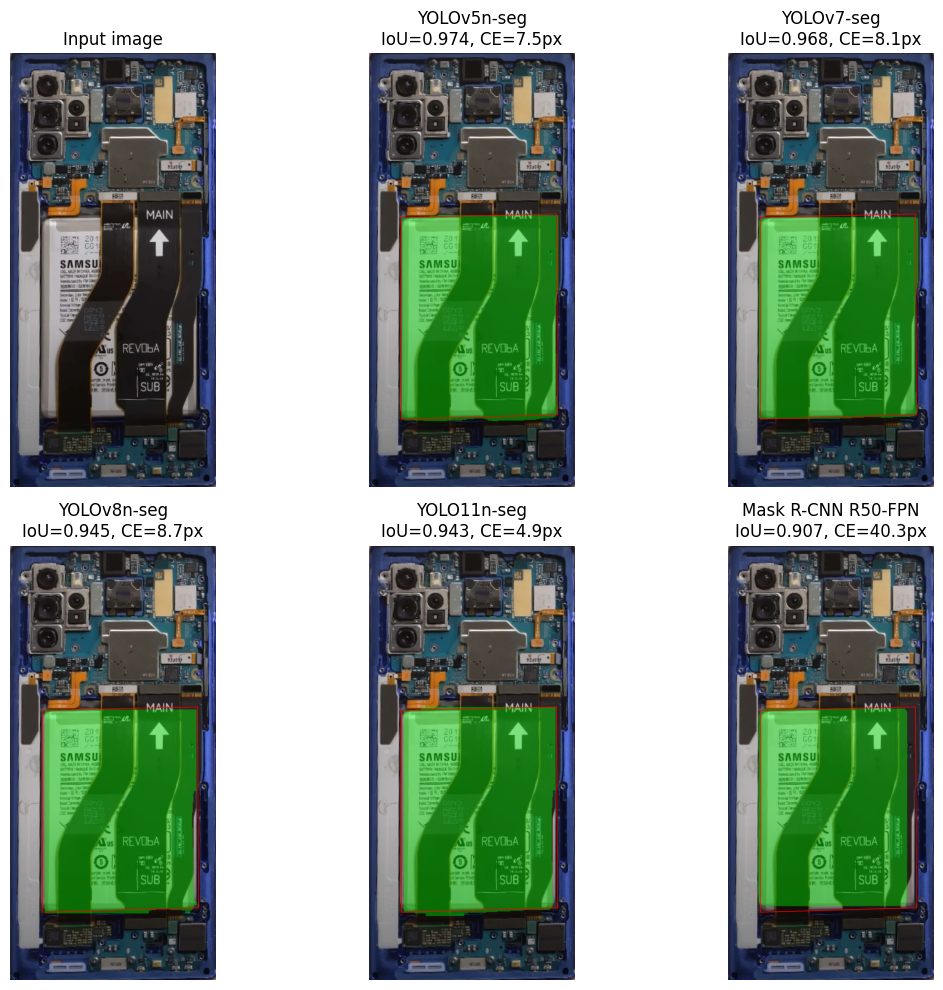

Saved improved qualitative figure to:
/content/drive/MyDrive/E-waste Battery Extraction CV/04_metrics_and_visualisations/first_5_model_eval_selected_test/qualitative_examples/qualitative_2x3_with_gt_CamScanner_08-09-2025_06.15_111.png


In [ ]:
# ============================================================
# Improved 2 x 3 qualitative comparison plot
# Green = prediction, Red outline = ground truth
# ============================================================

gt_mask = yolo_label_to_mask(
    EVAL_LBL_DIR / f"{QUAL_IMAGE_PATH.stem}.txt",
    input_rgb.shape
)

model_masks = [
    ("YOLOv5n-seg", mask_yolov5),
    ("YOLOv7-seg", mask_yolov7),
    ("YOLOv8n-seg", mask_yolov8),
    ("YOLO11n-seg", mask_yolo11),
    ("Mask R-CNN R50-FPN", mask_maskrcnn),
]

qual_images = [("Input image", input_rgb)]

for name, pred_mask in model_masks:
    iou, ce = single_image_iou_and_centroid(pred_mask, gt_mask)

    title = f"{name}\nIoU={iou:.3f}, CE={ce:.1f}px"
    overlay = overlay_pred_and_gt(input_rgb, pred_mask, gt_mask)

    qual_images.append((title, overlay))

fig, axes = plt.subplots(2, 3, figsize=(12, 10))

for ax, (title, img) in zip(axes.flatten(), qual_images):
    ax.imshow(img)
    ax.set_title(title, fontsize=12)
    ax.axis("off")

plt.tight_layout()

qual_fig_path = QUAL_OUT / f"qualitative_2x3_with_gt_{QUAL_IMAGE_PATH.stem}.png"
plt.savefig(qual_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved improved qualitative figure to:")
print(qual_fig_path)